## Load Data and Inspection

In [1]:
import pandas as pd

cars = pd.read_csv("cars_multivariate.csv")

cars.head(n=2)

,mpg,cylinders,displacement,horsepower,weight,acceleration,model,origin,car_name
0,18.0,8,307.0,130.0,3504.0,12.0,70,1,chevrolet chevelle malibu
1,15.0,8,350.0,165.0,3693.0,11.5,70,1,buick skylark 320


In [2]:
cars['cylinders'].unique()

array([8, 4, 6, 3, 5])

In [3]:
cars['origin'].unique()

array([1, 3, 2])

In [4]:
cars['model'].unique()

array([70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82])

## Exploratory Data Analysis

#### 1. Explore Target Variable (MPG)

TARGET VARIABLE: MPG
count    392.00
mean      23.45
std        7.81
min        9.00
25%       17.00
50%       22.75
75%       29.00
max       46.60
Name: mpg, dtype: float64

Skewness: 0.4571
Mean:     23.4459
Median:   22.7500
Std:      7.8050


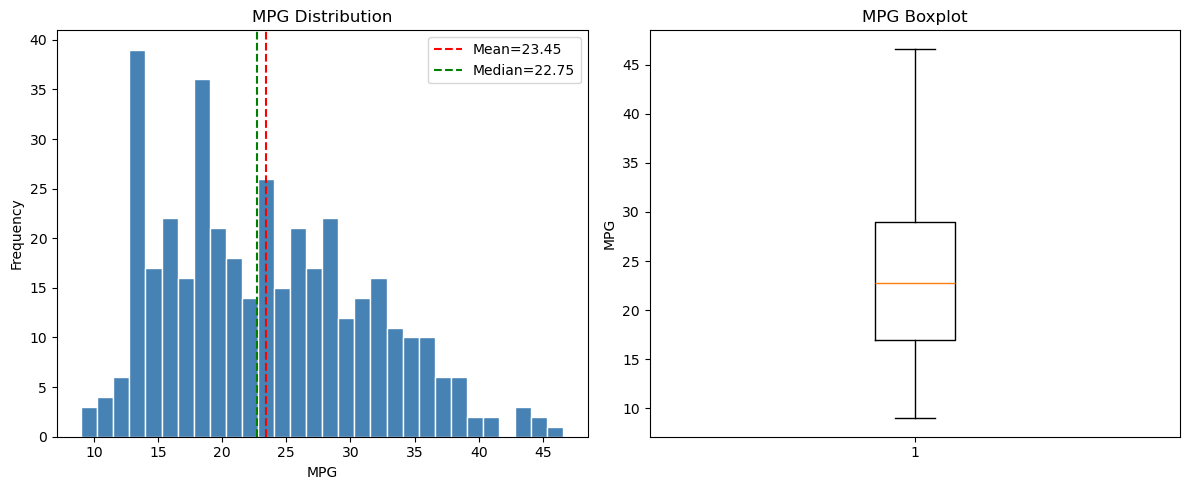

In [5]:
import matplotlib.pyplot as plt
import numpy as np

print("=" * 50)
print("TARGET VARIABLE: MPG")
print("=" * 50)
print(cars['mpg'].describe().round(2))
print(f"\nSkewness: {cars['mpg'].skew():.4f}")
print(f"Mean:     {cars['mpg'].mean():.4f}")
print(f"Median:   {cars['mpg'].median():.4f}")
print(f"Std:      {cars['mpg'].std():.4f}")

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].hist(cars['mpg'], bins=30, color='steelblue', edgecolor='white')
axes[0].axvline(cars['mpg'].mean(),   color='red',   linestyle='--', label=f'Mean={cars["mpg"].mean():.2f}')
axes[0].axvline(cars['mpg'].median(), color='green', linestyle='--', label=f'Median={cars["mpg"].median():.2f}')
axes[0].set_xlabel('MPG')
axes[0].set_ylabel('Frequency')
axes[0].set_title('MPG Distribution')
axes[0].legend()

axes[1].boxplot(cars['mpg'], vert=True)
axes[1].set_ylabel('MPG')
axes[1].set_title('MPG Boxplot')

plt.tight_layout()
plt.show()

### Summary

| Metric | Value |
|--------|-------|
| Mean | 23.45 |
| Median | 22.75 |
| Skewness | Mild positive |
| Outliers | Few at high end |

### Conclusion
- ✅ Mean ≈ Median → distribution is fairly symmetric
- ✅ Mild right skew → no log transform needed on target variable
- ⚠️ A few high mpg outliers → worth monitoring in residuals
- ✅ Linear models are appropriate for this target variable

### 2. Explore Feature Distributions

#### 2.a) Feature Skewness Summary

In [6]:
features = ['cylinders', 'weight', 'horsepower', 'displacement', 'acceleration', 'model', 'origin']

print("=" * 55)
print("FEATURE SKEWNESS SUMMARY")
print("=" * 55)
print(f"{'Feature':<15} {'Skewness':>10}  {'Action':>25}")
print("=" * 55)
for col in features:
    skew   = cars[col].skew()
    action = "✅ No transform needed" if abs(skew) <= 1 else "⚠️ Consider log transform"
    print(f"{col:<15} {skew:>10.4f}  {action:>25}")
print("=" * 55)

FEATURE SKEWNESS SUMMARY
Feature           Skewness                     Action
cylinders           0.5081      ✅ No transform needed
weight              0.5196      ✅ No transform needed
horsepower          1.0873  ⚠️ Consider log transform
displacement        0.7017      ✅ No transform needed
acceleration        0.2916      ✅ No transform needed
model               0.0197      ✅ No transform needed
origin              0.9152      ✅ No transform needed


### Conclusion
- ✅ Only **horsepower** (skew=1.09) strictly requires log transformation
- ⚠️ **weight** (skew=0.52) and **displacement** (skew=0.70) are borderline
  — log transformation applied as a conservative preprocessing choice
- ✅ **acceleration** and **model** are normally distributed — no transform needed
- ✅ **cylinders** and **origin** are categorical — One-Hot Encoding applied

#### 2.b) Feature Distribution Histograms

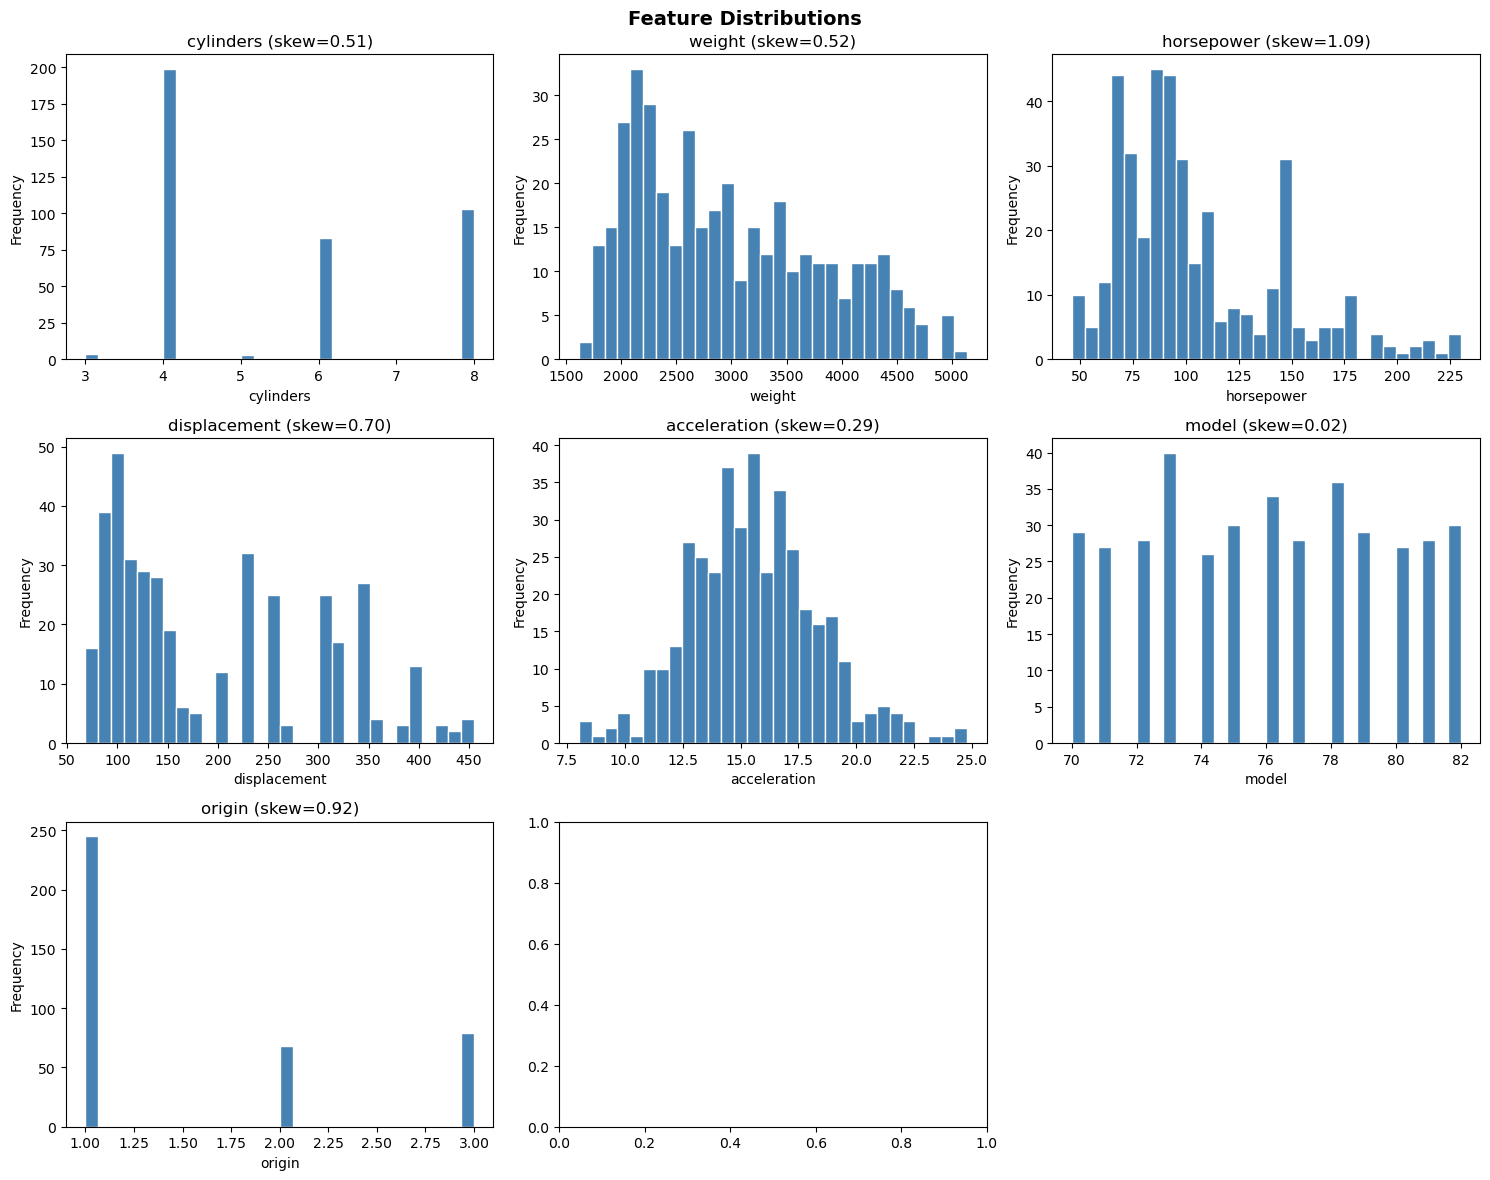

In [7]:
fig, axes = plt.subplots(3, 3, figsize=(15, 12))
axes = axes.flatten()

for i, col in enumerate(features):
    axes[i].hist(cars[col], bins=30, color='steelblue', edgecolor='white')
    axes[i].set_title(f'{col} (skew={cars[col].skew():.2f})')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Frequency')

axes[-1].set_visible(False)

plt.suptitle('Feature Distributions', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

### Conclusion — Feature Distributions
- ✅ horsepower (skew=1.09) → log transform required
- ⚠️ weight (skew=0.52) and displacement (skew=0.70) → borderline,
  log transform applied as conservative choice
- ✅ acceleration and model → normally distributed, no transform needed
- ✅ cylinders and origin → categorical, One-Hot Encoding applied
- ✅ American cars dominate origin — class imbalance worth noting

#### 2.c) Outlier Detection

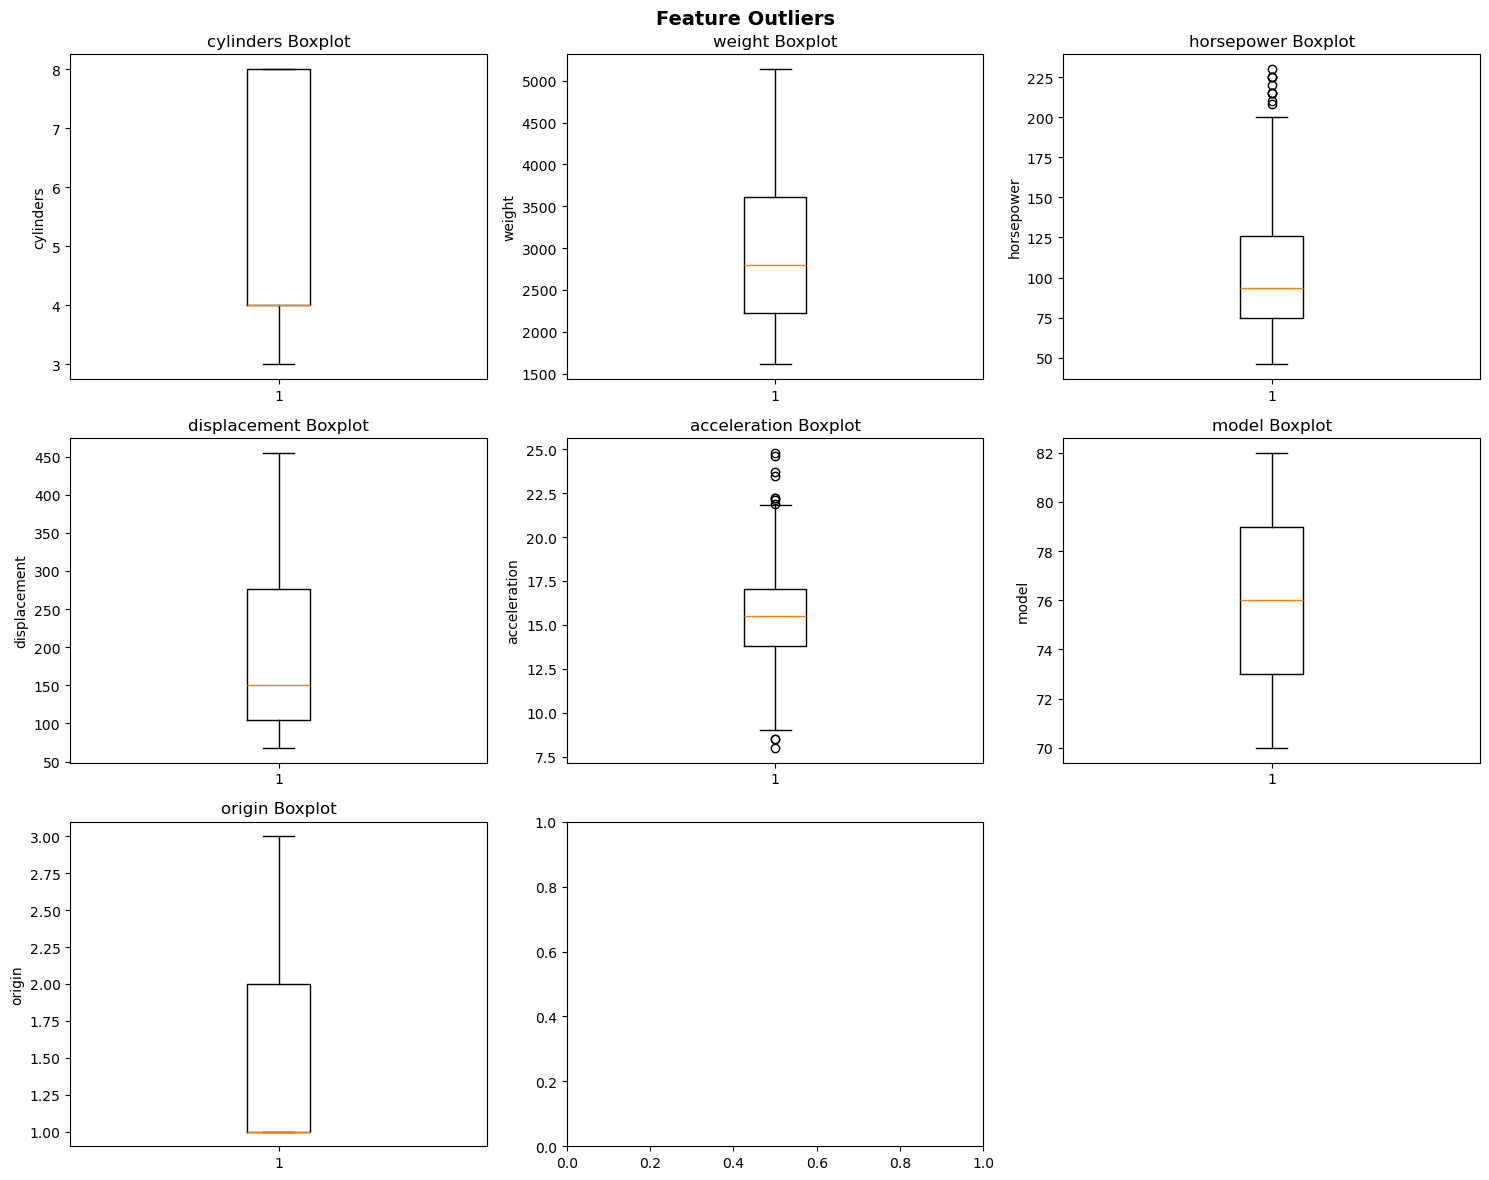

OUTLIER SUMMARY (values beyond 1.5 x IQR)
Feature             Q1      Q3     IQR  Outliers
cylinders         4.00    8.00    4.00         0
weight          2225.25  3614.75  1389.50         0
horsepower       75.00  126.00   51.00        10
displacement    105.00  275.75  170.75         0
acceleration     13.78   17.02    3.25        11
model            73.00   79.00    6.00         0
origin            1.00    2.00    1.00         0


In [8]:
# Boxplots
fig, axes = plt.subplots(3, 3, figsize=(15, 12))
axes = axes.flatten()

for i, col in enumerate(features):
    axes[i].boxplot(cars[col], vert=True)
    axes[i].set_title(f'{col} Boxplot')
    axes[i].set_ylabel(col)

axes[-1].set_visible(False)

plt.suptitle('Feature Outliers', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Outlier summary
print("=" * 55)
print("OUTLIER SUMMARY (values beyond 1.5 x IQR)")
print("=" * 55)
print(f"{'Feature':<15} {'Q1':>6}  {'Q3':>6}  {'IQR':>6}  {'Outliers':>8}")
print("=" * 55)
for col in features:
    Q1       = cars[col].quantile(0.25)
    Q3       = cars[col].quantile(0.75)
    IQR      = Q3 - Q1
    outliers = cars[(cars[col] < Q1 - 1.5 * IQR) | (cars[col] > Q3 + 1.5 * IQR)]
    print(f"{col:<15} {Q1:>6.2f}  {Q3:>6.2f}  {IQR:>6.2f}  {len(outliers):>8}")
print("=" * 55)

### Conclusion — Outlier Analysis
- ✅ Most features have zero outliers — clean dataset
- ⚠️ horsepower has 10 outliers → high performance cars
  → log transform will reduce their influence ✅
- ⚠️ acceleration has 11 outliers → extreme slow/fast cars
  → real values, not errors → keep in dataset
- ✅ No outliers removed — all values are plausible real-world cars
- ✅ Log transform on horsepower is further confirmed as correct

### 3. Check Relationships with Target

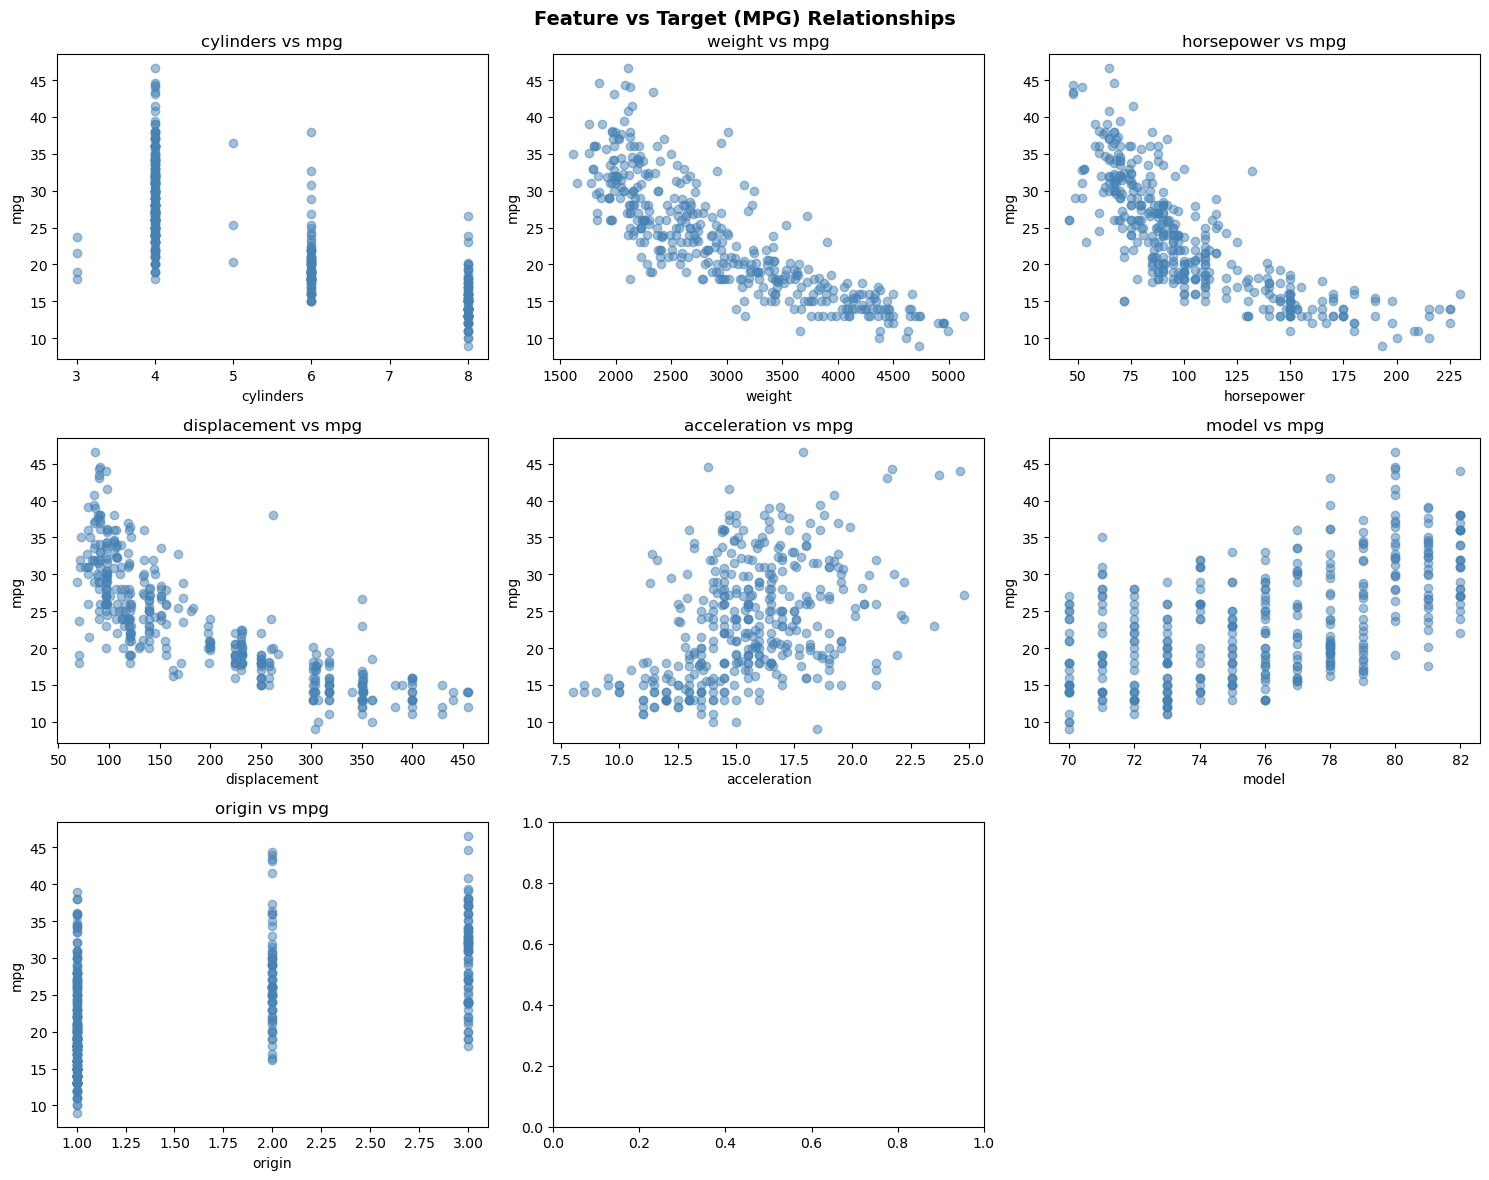

CORRELATION WITH TARGET (MPG)
Feature          Correlation          Relationship
weight               -0.8322       ✅ Strong linear
displacement         -0.8051       ✅ Strong linear
horsepower           -0.7784       ✅ Strong linear
cylinders            -0.7776       ✅ Strong linear
acceleration          0.4233    ⚠️ Moderate linear
origin                0.5652       ✅ Strong linear
model                 0.5805       ✅ Strong linear


In [9]:
# Scatter plots
fig, axes = plt.subplots(3, 3, figsize=(15, 12))
axes = axes.flatten()

for i, col in enumerate(features):
    axes[i].scatter(cars[col], cars['mpg'], alpha=0.5, color='steelblue')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('mpg')
    axes[i].set_title(f'{col} vs mpg')

axes[-1].set_visible(False)

plt.suptitle('Feature vs Target (MPG) Relationships', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Correlation with target
print("=" * 50)
print("CORRELATION WITH TARGET (MPG)")
print("=" * 50)
corr_with_target = cars[features + ['mpg']].corr()['mpg'].drop('mpg').sort_values()
print(f"{'Feature':<15} {'Correlation':>12}  {'Relationship':>20}")
print("=" * 50)
for col, corr in corr_with_target.items():
    if abs(corr) >= 0.5:
        relationship = "✅ Strong linear"
    elif abs(corr) >= 0.3:
        relationship = "⚠️ Moderate linear"
    else:
        relationship = "❌ Weak/Non-linear"
    print(f"{col:<15} {corr:>12.4f}  {relationship:>20}")
print("=" * 50)

### 4. Check Multicollinearity Between Features

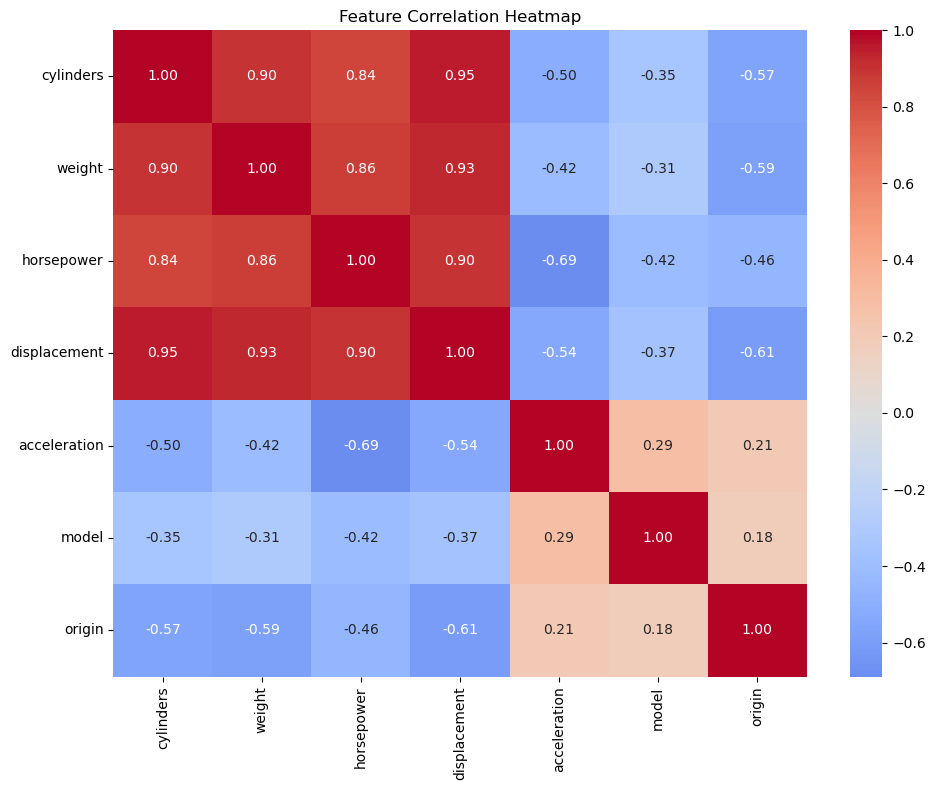

VARIANCE INFLATION FACTOR (VIF)
Feature              VIF             Interpretation
displacement     10.8231  ❌ Severe multicollinearity
weight           10.5798  ❌ Severe multicollinearity
horsepower        9.2989  ⚠️ Moderate multicollinearity
acceleration      2.6191     ✅ No multicollinearity
model             1.2446     ✅ No multicollinearity

High multicollinearity handled by:
  Lasso         → zeros out redundant features
  Ridge         → shrinks correlated coefficients
  PCA           → compresses correlated features
  Random Forest → handles naturally


In [10]:
import seaborn as sns
import matplotlib.pyplot as plt
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.preprocessing import StandardScaler
import pandas as pd

# --- Correlation Heatmap ---
fig, ax = plt.subplots(figsize=(10, 8))
corr_matrix = cars[features].corr()
sns.heatmap(corr_matrix,
            annot=True,
            fmt='.2f',
            cmap='coolwarm',
            center=0,
            ax=ax)
ax.set_title('Feature Correlation Heatmap')
plt.tight_layout()
plt.show()

# --- VIF Check ---
numerical_only = ['weight', 'horsepower', 'displacement',
                   'acceleration', 'model']
X_vif    = cars[numerical_only].dropna()

# Scale before VIF calculation
scaler   = StandardScaler()
X_scaled = pd.DataFrame(
    scaler.fit_transform(X_vif),
    columns=numerical_only
)

vif_data = pd.DataFrame({
    'Feature': numerical_only,
    'VIF':     [variance_inflation_factor(X_scaled.values, i)
                for i in range(X_scaled.shape[1])]
}).sort_values('VIF', ascending=False)

print("=" * 55)
print("VARIANCE INFLATION FACTOR (VIF)")
print("=" * 55)
print(f"{'Feature':<15} {'VIF':>8}  {'Interpretation':>25}")
print("=" * 55)
for _, row in vif_data.iterrows():
    if row['VIF'] >= 10:
        interpretation = "❌ Severe multicollinearity"
    elif row['VIF'] >= 5:
        interpretation = "⚠️ Moderate multicollinearity"
    else:
        interpretation = "✅ No multicollinearity"
    print(f"{row['Feature']:<15} {row['VIF']:>8.4f}  {interpretation:>25}")
print("=" * 55)
print("\nHigh multicollinearity handled by:")
print("  Lasso         → zeros out redundant features")
print("  Ridge         → shrinks correlated coefficients")
print("  PCA           → compresses correlated features")
print("  Random Forest → handles naturally")
print("=" * 55)

### 5. Check Linear Model Assumptions

#### 5.a) Check Assumption 1: linearity

In [11]:
from scipy import stats

print("=" * 55)
print("ASSUMPTION 1: LINEARITY")
print("=" * 55)
numerical_to_check = ['weight', 'horsepower', 'displacement',
                       'acceleration', 'model']
print(f"{'Feature':<15} {'Correlation':>12}  {'P-value':>10}  {'Result':>20}")
print("=" * 55)
for col in numerical_to_check:
    corr, p_value = stats.pearsonr(cars[col].dropna(),
                                    cars['mpg'].dropna())
    result = "✅ Linear" if p_value < 0.05 else "❌ Not linear"
    print(f"{col:<15} {corr:>12.4f}  {p_value:>10.4f}  {result:>20}")
print("=" * 55)

ASSUMPTION 1: LINEARITY
Feature          Correlation     P-value                Result
weight               -0.8322      0.0000              ✅ Linear
horsepower           -0.7784      0.0000              ✅ Linear
displacement         -0.8051      0.0000              ✅ Linear
acceleration          0.4233      0.0000              ✅ Linear
model                 0.5805      0.0000              ✅ Linear


#### 5.b) Check Assumption 2: Multicollinearity (VIF)

In [12]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.preprocessing import StandardScaler

print("=" * 55)
print("ASSUMPTION 2: MULTICOLLINEARITY (VIF)")
print("=" * 55)

numerical_only = ['weight', 'horsepower', 'displacement',
                   'acceleration', 'model']
X_vif    = cars[numerical_only].dropna()
scaler   = StandardScaler()
X_scaled = pd.DataFrame(
    scaler.fit_transform(X_vif),
    columns=numerical_only
)

vif_data = pd.DataFrame({
    'Feature': numerical_only,
    'VIF':     [variance_inflation_factor(X_scaled.values, i)
                for i in range(X_scaled.shape[1])]
}).sort_values('VIF', ascending=False)

print(f"{'Feature':<15} {'VIF':>8}  {'Result':>25}")
print("=" * 55)
for _, row in vif_data.iterrows():
    if row['VIF'] >= 10:
        result = "❌ Severe multicollinearity"
    elif row['VIF'] >= 5:
        result = "⚠️ Moderate multicollinearity"
    else:
        result = "✅ No multicollinearity"
    print(f"{row['Feature']:<15} {row['VIF']:>8.4f}  {result:>25}")
print("=" * 55)

ASSUMPTION 2: MULTICOLLINEARITY (VIF)
Feature              VIF                     Result
displacement     10.8231  ❌ Severe multicollinearity
weight           10.5798  ❌ Severe multicollinearity
horsepower        9.2989  ⚠️ Moderate multicollinearity
acceleration      2.6191     ✅ No multicollinearity
model             1.2446     ✅ No multicollinearity


#### Conclusion — Linear Model Assumptions

| Assumption | Status | Notes |
|---|---|---|
| Linearity | ✅ Met | Strong linear relationships confirmed |
| Multicollinearity | ⚠️ Severe | cylinders, weight, horsepower, displacement highly correlated — handled by Lasso/Ridge/PCA |

- ✅ One out of two assumptions fully met
- ⚠️ Multicollinearity is the only concern
  → confirmed by heatmap (0.84-0.95) and high VIF values
  → all four models chosen are equipped to handle this
- ✅ Linear models (Lasso, Ridge, PCA) are appropriate
- ✅ Random Forest included to capture any remaining
  non-linear patterns

### EDA-Based Feature Transformation Assessment

#### Evidence Summary

| Feature | Skewness | Scatter vs MPG | Outliers | Log Needed? |
|---------|----------|----------------|----------|-------------|
| weight | 0.52 | ✅ Linear | 0 | ❌ Not strictly needed |
| horsepower | 1.09 | ⚠️ Slight curve | 10 | ✅ Yes — clear evidence |
| displacement | 0.70 | ⚠️ Slight curve | 0 | ⚠️ Borderline |

#### Assessment Per Feature

**weight (skew=0.52)**
- Skewness is mild → no log transform needed
- Scatter plot shows linear relationship with mpg → no log needed
- Zero outliers detected → no log needed
- **Verdict: ❌ Log transform not strictly necessary**

**horsepower (skew=1.09)**
- Skewness exceeds threshold (>1) → log transform needed ✅
- Scatter plot shows slight curve vs mpg → log transform helps ✅
- 10 outliers detected → log transform reduces their influence ✅
- **Verdict: ✅ Log transform clearly justified**

**displacement (skew=0.70)**
- Skewness is borderline → log transform optional
- Scatter plot shows slight curve vs mpg → maybe
- Zero outliers detected → no log needed
- **Verdict: ⚠️ Borderline — log transform not strongly justified**

#### Conclusion
- ✅ Only **horsepower** has clear evidence for log transformation
- ⚠️ **weight** and **displacement** were log transformed as a
  conservative preprocessing choice — not strictly required by EDA
- Both pipeline versions will be tested and compared: log transform horsepower only

### Import Libraries

In [13]:
# Data manipulation
import numpy as np
import pandas as pd

# Visualisation
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocessing
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# Model selection
from sklearn.model_selection import train_test_split, GridSearchCV

# Models
from sklearn.linear_model import LassoCV, RidgeCV, LinearRegression
from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestRegressor


# Evaluation metrics
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from sklearn.model_selection import cross_val_score


# Statistical tests
from scipy import stats
from scipy.stats import levene

# Multicollinearity check
from statsmodels.stats.outliers_influence import variance_inflation_factor

## Lasso CV Model

### 1. Lasso CV Pipeline

In [14]:
X = cars[['cylinders', 'weight', 'horsepower', 'displacement',
          'acceleration', 'model', 'origin']].copy()
y = cars['mpg']

# Log transform horsepower only
X['log_horsepower'] = np.log(X['horsepower'])
X = X.drop(columns=['horsepower'])

# Feature groups
numerical_features   = ['weight', 'log_horsepower', 'displacement',
                         'acceleration', 'model']
categorical_features = ['origin', 'cylinders']

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Preprocessor
preprocessor_lasso = ColumnTransformer([
    ('num', StandardScaler(), numerical_features),
    ('cat', OneHotEncoder(drop='first', sparse_output=False), categorical_features)
])

# Pipeline
lasso_cv_pipeline = Pipeline([
    ('preprocessor', preprocessor_lasso),
    ('model', LassoCV(cv=5, random_state=42))
])

lasso_cv_pipeline.fit(X_train, y_train)

lasso_train_r2 = r2_score(y_train, lasso_cv_pipeline.predict(X_train))
lasso_test_r2  = r2_score(y_test,  lasso_cv_pipeline.predict(X_test))

print(f"Best alpha:   {lasso_cv_pipeline.named_steps['model'].alpha_:.4f}")
print(f"Train R²:     {lasso_train_r2:.4f}")
print(f"Test  R²:     {lasso_test_r2:.4f}")
print(f"Gap:          {lasso_train_r2 - lasso_test_r2:.4f}")

Best alpha:   0.0133
Train R²:     0.8603
Test  R²:     0.8317
Gap:          0.0286


### 2. Lasso Alpha Values & Visualization:

Number of alphas tested: 100
Smallest alpha tested:   0.006637
Largest alpha tested:    6.637367
Best alpha chosen:       0.013336


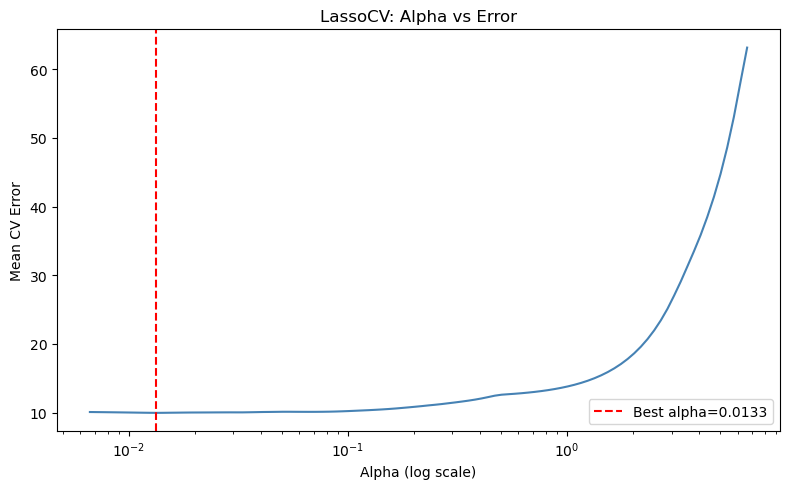

In [15]:
alphas_tested = lasso_cv_pipeline.named_steps['model'].alphas_
best_alpha    = lasso_cv_pipeline.named_steps['model'].alpha_

print(f"Number of alphas tested: {len(alphas_tested)}")
print(f"Smallest alpha tested:   {alphas_tested.min():.6f}")
print(f"Largest alpha tested:    {alphas_tested.max():.6f}")
print(f"Best alpha chosen:       {best_alpha:.6f}")

# Visualization
mse_scores = lasso_cv_pipeline.named_steps['model'].mse_path_.mean(axis=1)

plt.figure(figsize=(8, 5))
plt.plot(alphas_tested, mse_scores, color='steelblue')
plt.axvline(best_alpha, color='red', linestyle='--',
            label=f'Best alpha={best_alpha:.4f}')
plt.xscale('log')
plt.xlabel('Alpha (log scale)')
plt.ylabel('Mean CV Error')
plt.title('LassoCV: Alpha vs Error')
plt.legend()
plt.tight_layout()
plt.show()

### 3. Check Assumption 3: Normality of Residuals

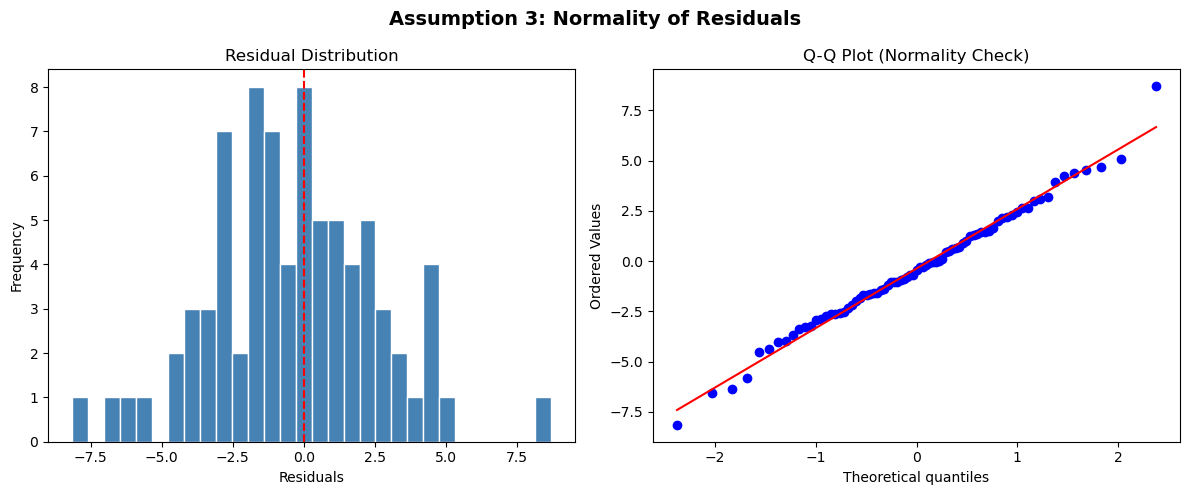


ASSUMPTION 3: NORMALITY OF RESIDUALS
Shapiro-Wilk Test:
Statistic:  0.9921
P-value:    0.9149
✅ Residuals are normally distributed (p > 0.05)


In [16]:
from scipy import stats

residuals = y_test - lasso_cv_pipeline.predict(X_test)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].hist(residuals, bins=30, color='steelblue', edgecolor='white')
axes[0].axvline(x=0, color='red', linestyle='--')
axes[0].set_xlabel('Residuals')
axes[0].set_ylabel('Frequency')
axes[0].set_title('Residual Distribution')

stats.probplot(residuals, dist="norm", plot=axes[1])
axes[1].set_title('Q-Q Plot (Normality Check)')

plt.suptitle('Assumption 3: Normality of Residuals',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

stat, p_value = stats.shapiro(residuals)

print("\n" + "=" * 55)
print("ASSUMPTION 3: NORMALITY OF RESIDUALS")
print("Shapiro-Wilk Test:")
print("=" * 55)
print(f"Statistic:  {stat:.4f}")
print(f"P-value:    {p_value:.4f}")
if p_value > 0.05:
    print("✅ Residuals are normally distributed (p > 0.05)")
else:
    print("⚠️ Residuals not normally distributed (p < 0.05)")
print("=" * 55)

### 4. Check Assumption 4: Homoscedasticity

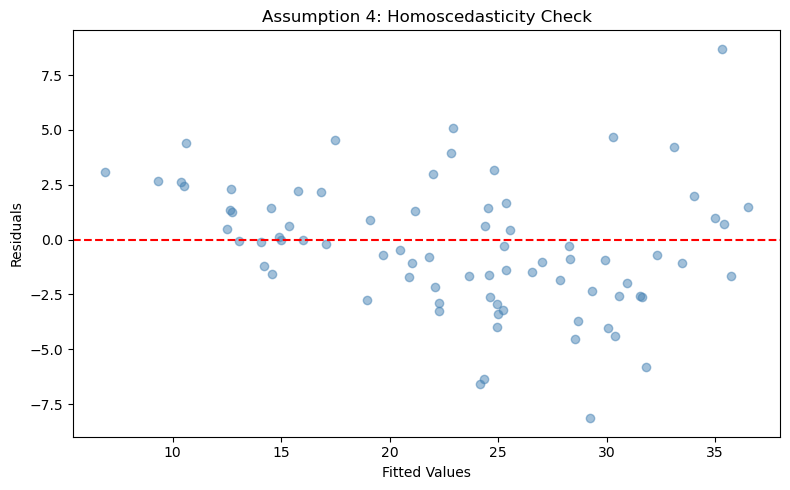


ASSUMPTION 4: HOMOSCEDASTICITY
Levene Test:
Statistic:  0.2850
P-value:    0.5950
✅ Constant variance confirmed (p > 0.05)


In [17]:
from scipy.stats import levene
import numpy as np

y_pred    = lasso_cv_pipeline.predict(X_test)
residuals = y_test - y_pred

# Split residuals into low and high fitted value groups
median_pred = np.median(y_pred)
low_resid   = residuals[y_pred <= median_pred]
high_resid  = residuals[y_pred >  median_pred]

# Levene test
lev_stat, lev_p = levene(low_resid, high_resid)

# Plot
fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(y_pred, residuals, alpha=0.5, color='steelblue')
ax.axhline(y=0, color='red', linestyle='--')
ax.set_xlabel('Fitted Values')
ax.set_ylabel('Residuals')
ax.set_title('Assumption 4: Homoscedasticity Check')
plt.tight_layout()
plt.show()

print("\n" + "=" * 55)
print("ASSUMPTION 4: HOMOSCEDASTICITY")
print("Levene Test:")
print("=" * 55)
print(f"Statistic:  {lev_stat:.4f}")
print(f"P-value:    {lev_p:.4f}")
if lev_p > 0.05:
    print("✅ Constant variance confirmed (p > 0.05)")
else:
    print("⚠️ Unequal variance detected (p < 0.05)")
    print("   → consider log transform on y")
print("=" * 55)

### 5. Residual plot

A residual plot is essentially a diagnostic tool — it checks whether your model's assumptions are valid and where it's failing.

If errors are random → your model has captured all the patterns.

If errors show a pattern → your model is leaving something on the table.

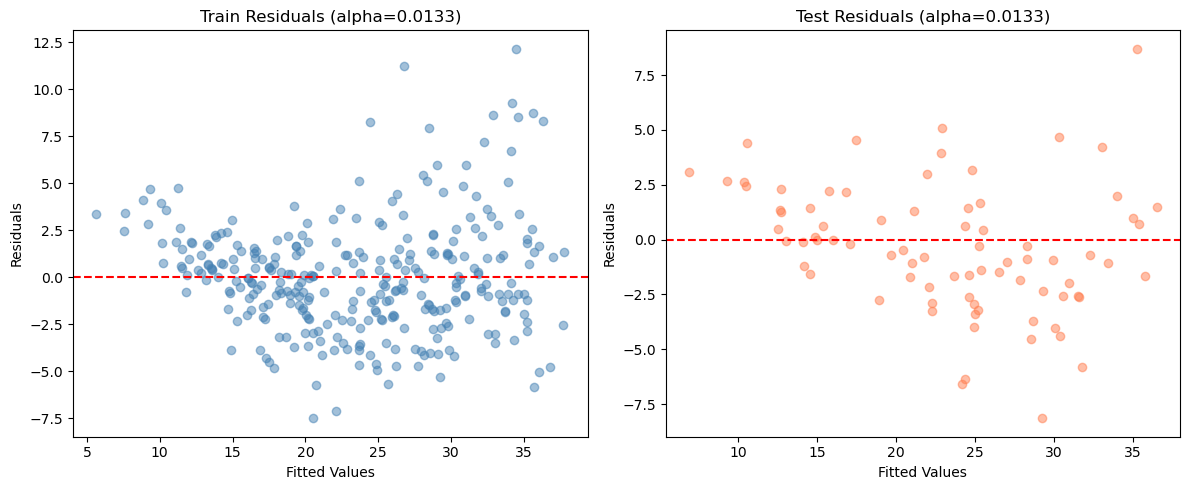

In [18]:
import matplotlib.pyplot as plt
import numpy as np

# Get predictions
y_pred_train = lasso_cv_pipeline.predict(X_train)
y_pred_test = lasso_cv_pipeline.predict(X_test)

# Calculate residuals
residuals_train = y_train - y_pred_train
residuals_test = y_test - y_pred_test

# Plot
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Training residuals
axes[0].scatter(y_pred_train, residuals_train, alpha=0.5, color='steelblue')
axes[0].axhline(y=0, color='red', linestyle='--')
axes[0].set_xlabel('Fitted Values')
axes[0].set_ylabel('Residuals')
axes[0].set_title(f'Train Residuals (alpha={best_alpha:.4f})')

# Test residuals
axes[1].scatter(y_pred_test, residuals_test, alpha=0.5, color='coral')
axes[1].axhline(y=0, color='red', linestyle='--')
axes[1].set_xlabel('Fitted Values')
axes[1].set_ylabel('Residuals')
axes[1].set_title(f'Test Residuals (alpha={best_alpha:.4f})')

plt.tight_layout()
plt.show()

### 6. Feature Selection by Lasso

In [19]:
feature_names = (
    lasso_cv_pipeline.named_steps['preprocessor']
    .get_feature_names_out()
)
coefficients = lasso_cv_pipeline.named_steps['model'].coef_

coef_df = pd.DataFrame({
    'feature':     feature_names,
    'coefficient': coefficients
}).sort_values('coefficient', key=abs, ascending=False)

# Summary
kept   = coef_df[coef_df['coefficient'] != 0]
zeroed = coef_df[coef_df['coefficient'] == 0]

print(f"Features kept:    {len(kept)}")
print(f"Features removed: {len(zeroed)}")

print("\nFeature coefficients (0 = dropped by Lasso):")
print(coef_df.to_string(index=False))

print("\nRemoved features:")
print(zeroed['feature'].tolist())


Features kept:    10
Features removed: 1

Feature coefficients (0 = dropped by Lasso):
            feature  coefficient
num__log_horsepower    -3.447679
        num__weight    -2.918305
   cat__cylinders_4     2.887390
      cat__origin_3     2.642665
         num__model     2.569587
      cat__origin_2     1.679916
   cat__cylinders_8     1.557972
   cat__cylinders_5     1.278212
  num__displacement     1.179585
  num__acceleration    -0.802458
   cat__cylinders_6    -0.000000

Removed features:
['cat__cylinders_6']


### 7. Prediction vs Actual Comparison

 Actual  Predicted  Error
   26.0      27.03  -1.03
   21.6      24.99  -3.39
   36.1      35.41   0.69
   26.0      24.54   1.46
   27.0      29.33  -2.33
   28.0      30.58  -2.58
   13.0      10.54   2.46
   26.0      30.39  -4.39
   19.0      19.68  -0.68
   29.0      31.56  -2.56
   15.0      12.71   2.29
   19.0      22.26  -3.26
   16.9      17.08  -0.18
   29.0      29.93  -0.93
   16.2      18.95  -2.75


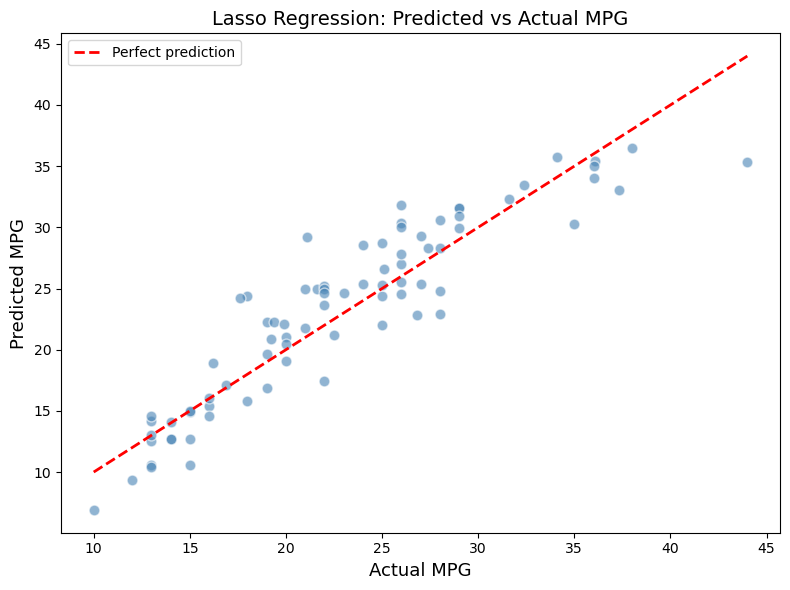

In [20]:
y_pred = lasso_cv_pipeline.predict(X_test)

comparison = pd.DataFrame({
    'Actual':    y_test.values,
    'Predicted': y_pred.round(2),
    'Error':     (y_test.values - y_pred).round(2)
})
print(comparison.head(15).to_string(index=False))

plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, alpha=0.6, color='steelblue', edgecolors='white', s=60)
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         'r--', linewidth=2, label='Perfect prediction')
plt.xlabel('Actual MPG', fontsize=13)
plt.ylabel('Predicted MPG', fontsize=13)
plt.title('Lasso Regression: Predicted vs Actual MPG', fontsize=14)
plt.legend()
plt.tight_layout()
plt.savefig('predicted_vs_actual.png', dpi=150)
plt.show()

### 8. Lasso Coefficents and Equation

In [21]:
lasso_intercept  = lasso_cv_pipeline.named_steps['model'].intercept_
lasso_coef       = lasso_cv_pipeline.named_steps['model'].coef_
lasso_features   = lasso_cv_pipeline.named_steps['preprocessor'].get_feature_names_out()

print("=" * 60)
print("LASSO EQUATION:")
print("=" * 60)
print(f"MPG = {lasso_intercept:.4f}")
for feature, coef in zip(lasso_features, lasso_coef):
    if coef != 0:  # only show kept features
        print(f"      {coef:+.4f} * {feature}")


LASSO EQUATION:
MPG = 20.9411
      -2.9183 * num__weight
      -3.4477 * num__log_horsepower
      +1.1796 * num__displacement
      -0.8025 * num__acceleration
      +2.5696 * num__model
      +1.6799 * cat__origin_2
      +2.6427 * cat__origin_3
      +2.8874 * cat__cylinders_4
      +1.2782 * cat__cylinders_5
      +1.5580 * cat__cylinders_8


### 9. Lasso Predicting MPG 

In [22]:
new_car = pd.DataFrame({
    'weight':           [3000],   # actual weight = 3000 lbs
    'log_horsepower':   [np.log(100)],    # actual horsepower = 100
    'displacement':     [200],    # actual displacement = 200
    'acceleration':     [15.0],           # acceleration
    'model':            [80],             # model year = 1980
    'origin':           [3],              # 1=American, 2=European, 3=Japanese
    'cylinders':        [4]               # number of cylinders
})
lasso_pred = lasso_cv_pipeline.predict(new_car)[0]

print("=" * 40)
print("NEW CAR SPECIFICATIONS:")
print("=" * 40)
print(f"  Weight:       3000 lbs")
print(f"  Horsepower:   100 hp")
print(f"  Displacement: 200 cc")
print(f"  Acceleration: 15.0")
print(f"  Model year:   1980")
print(f"  Origin:       Japan (3)")
print(f"  Cylinders:    4")
print("=" * 40)
print(f"PREDICTED MPG: {lasso_pred:.2f} mpg")
print("=" * 40)

NEW CAR SPECIFICATIONS:
  Weight:       3000 lbs
  Horsepower:   100 hp
  Displacement: 200 cc
  Acceleration: 15.0
  Model year:   1980
  Origin:       Japan (3)
  Cylinders:    4
PREDICTED MPG: 29.16 mpg


## Ridge Model

### 1. Ridge CV Pipeline

In [23]:
X = cars[['cylinders', 'weight', 'horsepower', 'displacement',
          'acceleration', 'model', 'origin']].copy()
y = cars['mpg']

# Log transform horsepower only
X['log_horsepower'] = np.log(X['horsepower'])
X = X.drop(columns=['horsepower'])

# Feature groups
numerical_features   = ['weight', 'log_horsepower', 'displacement',
                         'acceleration', 'model']
categorical_features = ['origin', 'cylinders']

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Preprocessor
preprocessor_ridge = ColumnTransformer([
    ('num', StandardScaler(), numerical_features),
    ('cat', OneHotEncoder(drop='first', sparse_output=False), categorical_features)
])

# Pipeline
ridge_pipeline = Pipeline([
    ('preprocessor', preprocessor_ridge),
    ('model', RidgeCV(
        alphas=np.logspace(-4, 4, 100),
        cv=5
    ))
])

ridge_pipeline.fit(X_train, y_train)

ridge_train_r2 = r2_score(y_train, ridge_pipeline.predict(X_train))
ridge_test_r2  = r2_score(y_test,  ridge_pipeline.predict(X_test))

print(f"Best alpha:   {ridge_pipeline.named_steps['model'].alpha_:.4f}")
print(f"Train R²:     {ridge_train_r2:.4f}")
print(f"Test  R²:     {ridge_test_r2:.4f}")
print(f"Gap:          {ridge_train_r2 - ridge_test_r2:.4f}")

Best alpha:   5.8570
Train R²:     0.8581
Test  R²:     0.8301
Gap:          0.0279


### 2. Check Assumption 3: Normality of Residuals

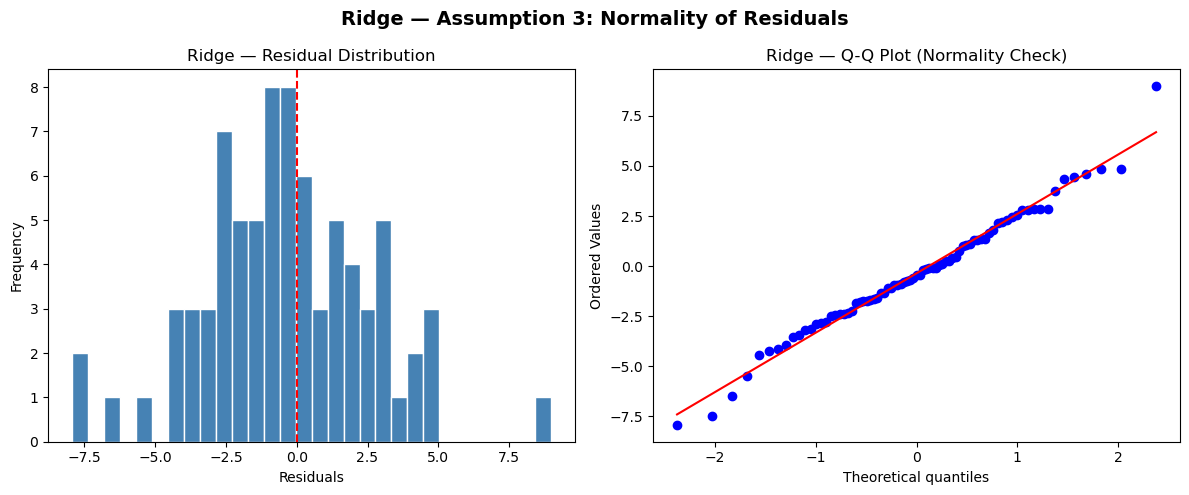

RIDGE — ASSUMPTION 3: NORMALITY OF RESIDUALS
Shapiro-Wilk Test:
Statistic:  0.9872
P-value:    0.6231
✅ Residuals are normally distributed (p > 0.05)


In [24]:
from scipy import stats

residuals_ridge = y_test - ridge_pipeline.predict(X_test)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].hist(residuals_ridge, bins=30, color='steelblue', edgecolor='white')
axes[0].axvline(x=0, color='red', linestyle='--')
axes[0].set_xlabel('Residuals')
axes[0].set_ylabel('Frequency')
axes[0].set_title('Ridge — Residual Distribution')

stats.probplot(residuals_ridge, dist="norm", plot=axes[1])
axes[1].set_title('Ridge — Q-Q Plot (Normality Check)')

plt.suptitle('Ridge — Assumption 3: Normality of Residuals',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

stat, p_value = stats.shapiro(residuals_ridge)

print("=" * 55)
print("RIDGE — ASSUMPTION 3: NORMALITY OF RESIDUALS")
print("Shapiro-Wilk Test:")
print("=" * 55)
print(f"Statistic:  {stat:.4f}")
print(f"P-value:    {p_value:.4f}")
if p_value > 0.05:
    print("✅ Residuals are normally distributed (p > 0.05)")
else:
    print("⚠️ Residuals not normally distributed (p < 0.05)")
print("=" * 55)

### 3. Check Assumption 4: Homoscedasticity

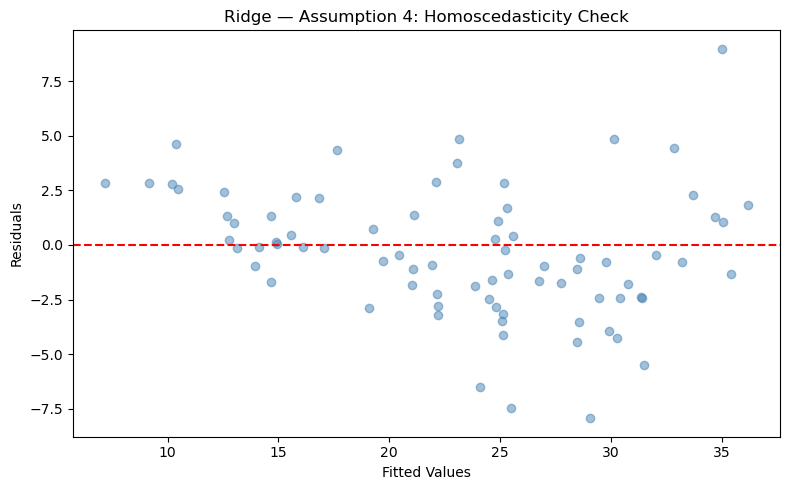


RIDGE — ASSUMPTION 4: HOMOSCEDASTICITY
Levene Test:
Statistic:  1.2530
P-value:    0.2665
✅ Constant variance confirmed (p > 0.05)


In [25]:
from scipy.stats import levene

y_pred_ridge    = ridge_pipeline.predict(X_test)
residuals_ridge = y_test - y_pred_ridge

median_pred = np.median(y_pred_ridge)
low_resid   = residuals_ridge[y_pred_ridge <= median_pred]
high_resid  = residuals_ridge[y_pred_ridge >  median_pred]

lev_stat, lev_p = levene(low_resid, high_resid)

fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(y_pred_ridge, residuals_ridge, alpha=0.5, color='steelblue')
ax.axhline(y=0, color='red', linestyle='--')
ax.set_xlabel('Fitted Values')
ax.set_ylabel('Residuals')
ax.set_title('Ridge — Assumption 4: Homoscedasticity Check')
plt.tight_layout()
plt.show()

print("\n" + "=" * 55)
print("RIDGE — ASSUMPTION 4: HOMOSCEDASTICITY")
print("Levene Test:")
print("=" * 55)
print(f"Statistic:  {lev_stat:.4f}")
print(f"P-value:    {lev_p:.4f}")
if lev_p > 0.05:
    print("✅ Constant variance confirmed (p > 0.05)")
else:
    print("⚠️ Unequal variance detected (p < 0.05)")
    print("   → consider log transform on y")
print("=" * 55)

### 4. Residual Plot

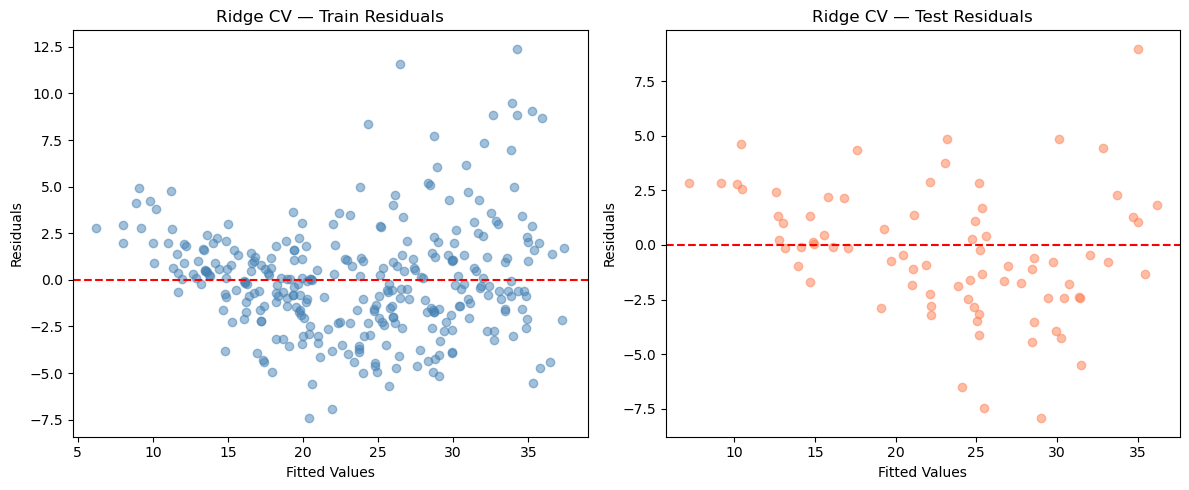

In [26]:
y_pred_train = ridge_pipeline.predict(X_train)
y_pred_test  = ridge_pipeline.predict(X_test)

residuals_train = y_train - y_pred_train
residuals_test  = y_test  - y_pred_test

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].scatter(y_pred_train, residuals_train, alpha=0.5, color='steelblue')
axes[0].axhline(y=0, color='red', linestyle='--')
axes[0].set_xlabel('Fitted Values')
axes[0].set_ylabel('Residuals')
axes[0].set_title('Ridge CV — Train Residuals')

axes[1].scatter(y_pred_test, residuals_test, alpha=0.5, color='coral')
axes[1].axhline(y=0, color='red', linestyle='--')
axes[1].set_xlabel('Fitted Values')
axes[1].set_ylabel('Residuals')
axes[1].set_title('Ridge CV — Test Residuals')

plt.tight_layout()
plt.show()

### 5. Ridge Alpha Values & Visualization:

Number of alphas tested: 100
Smallest alpha tested:   0.000100
Largest alpha tested:    10000.000000
Best alpha chosen:       5.857021


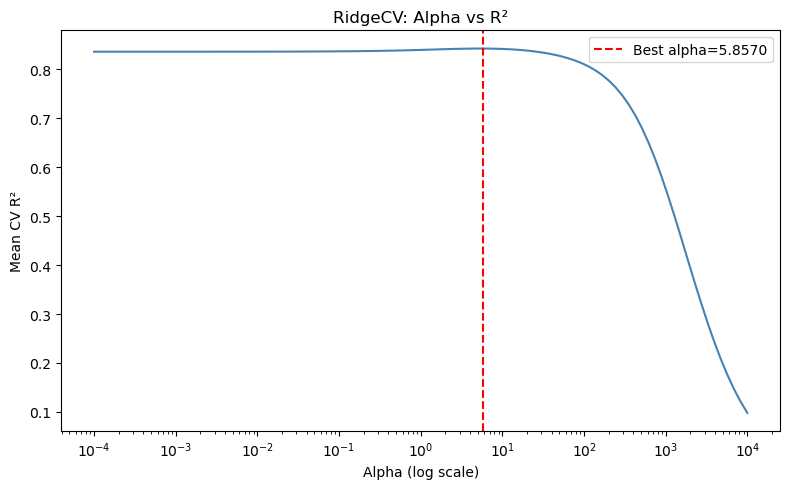

In [27]:
numerical_features   = ['weight', 'log_horsepower', 'displacement',
                         'acceleration', 'model']
categorical_features = ['origin', 'cylinders']

preprocessor = ColumnTransformer([
    ('num', StandardScaler(), numerical_features),
    ('cat', OneHotEncoder(drop='first', sparse_output=False), categorical_features)
])

# ============================================================
# RIDGE ALPHA SEARCH VISUALIZATION
# ============================================================
alphas  = np.logspace(-4, 4, 100)
mean_r2 = []

for alpha in alphas:
    ridge_temp = Pipeline([
        ('preprocessor', preprocessor),
        ('model', RidgeCV(alphas=alpha))   # ← Ridge not RidgeCV
    ])
    scores = cross_val_score(ridge_temp, X_train, y_train, cv=5, scoring='r2')
    mean_r2.append(scores.mean())

best_alpha = alphas[np.argmax(mean_r2)]

print(f"Number of alphas tested: {len(alphas)}")
print(f"Smallest alpha tested:   {alphas.min():.6f}")
print(f"Largest alpha tested:    {alphas.max():.6f}")
print(f"Best alpha chosen:       {best_alpha:.6f}")

plt.figure(figsize=(8, 5))
plt.plot(alphas, mean_r2, color='steelblue')
plt.axvline(best_alpha, color='red', linestyle='--',
            label=f'Best alpha={best_alpha:.4f}')
plt.xscale('log')
plt.xlabel('Alpha (log scale)')
plt.ylabel('Mean CV R²')
plt.title('RidgeCV: Alpha vs R²')
plt.legend()
plt.tight_layout()
plt.show()


### 6. Ridge Coefficients & Equation

In [28]:
ridge_intercept = ridge_pipeline.named_steps['model'].intercept_
ridge_coef      = ridge_pipeline.named_steps['model'].coef_
ridge_features  = ridge_pipeline.named_steps['preprocessor'].get_feature_names_out()

ridge_coef_df = pd.DataFrame({
    'feature':     ridge_features,
    'coefficient': ridge_coef
}).sort_values('coefficient', key=abs, ascending=False)


print("=" * 60)
print(" RIDGE EQUATION:")
print("=" * 60)
print(f"MPG = {ridge_intercept:.4f}")
for feature, coef in zip(ridge_features, ridge_coef):
    if coef != 0:  # only show kept features
        print(f"      {coef:+.4f} * {feature}")



 RIDGE EQUATION:
MPG = 22.0739
      -2.7911 * num__weight
      -3.2363 * num__log_horsepower
      +0.6861 * num__displacement
      -0.7483 * num__acceleration
      +2.5132 * num__model
      +1.3063 * cat__origin_2
      +2.2170 * cat__origin_3
      +1.8121 * cat__cylinders_4
      +0.5949 * cat__cylinders_5
      -1.0086 * cat__cylinders_6
      +0.7001 * cat__cylinders_8


### 7. Ridge Prediction vs Actual and Visualization

Ridge CV — Predicted vs Actual (first 15 rows):
 Actual  Predicted  Error
   26.0      26.96  -0.96
   21.6      25.07  -3.47
   36.1      35.04   1.06
   26.0      24.91   1.09
   27.0      29.45  -2.45
   28.0      30.41  -2.41
   13.0      10.45   2.55
   26.0      30.26  -4.26
   19.0      19.71  -0.71
   29.0      31.37  -2.37
   15.0      12.55   2.45
   19.0      22.20  -3.20
   16.9      17.05  -0.15
   29.0      29.77  -0.77
   16.2      19.08  -2.88


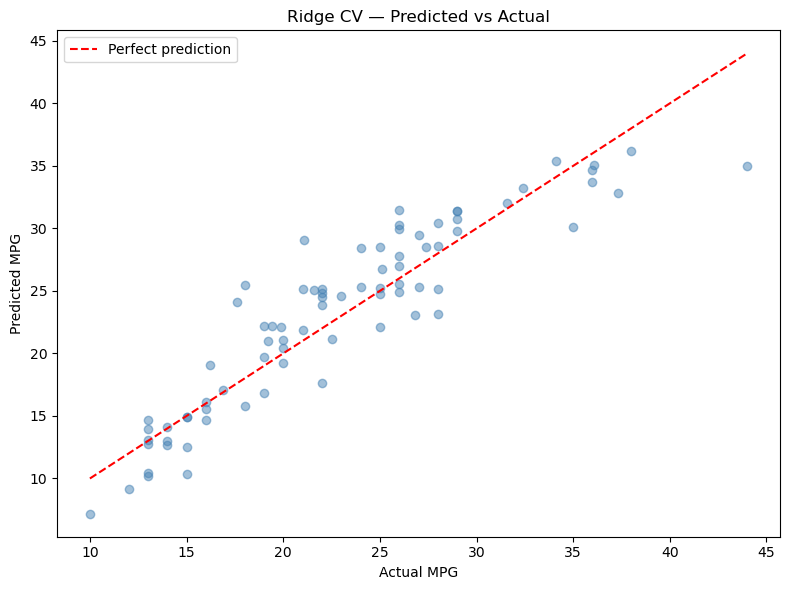

In [29]:
y_pred_test  = ridge_pipeline.predict(X_test)

ridge_pred_df = pd.DataFrame({
    'Actual':    y_test.values,
    'Predicted': y_pred_test,
    'Error':     y_test.values - y_pred_test
}).round(2)

print("Ridge CV — Predicted vs Actual (first 15 rows):")
print(ridge_pred_df.head(15).to_string(index=False))

fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(y_test, y_pred_test, alpha=0.5, color='steelblue')
ax.plot([y_test.min(), y_test.max()],
        [y_test.min(), y_test.max()],
        color='red', linestyle='--', label='Perfect prediction')
ax.set_xlabel('Actual MPG')
ax.set_ylabel('Predicted MPG')
ax.set_title('Ridge CV — Predicted vs Actual')
ax.legend()
plt.tight_layout()
plt.show()

### 8. Ridge Predicting MPG

In [30]:
new_car = pd.DataFrame({
    'weight':       [np.log(3000)],
    'log_horsepower':   [np.log(100)],
    'displacement': [np.log(200)],
    'acceleration':     [15.0],
    'model':            [80],
    'origin':           [3],
    'cylinders':        [4]
})

ridge_pred = ridge_pipeline.predict(new_car)[0]

print("=" * 40)
print("NEW CAR SPECIFICATIONS:")
print("=" * 40)
print(f"  Weight:       3000 lbs")
print(f"  Horsepower:   100 hp")
print(f"  Displacement: 200 cc")
print(f"  Acceleration: 15.0")
print(f"  Model year:   1980")
print(f"  Origin:       Japan (3)")
print(f"  Cylinders:    4")
print("=" * 40)
print(f"  PREDICTED MPG: {ridge_pred:.2f} mpg")
print("=" * 40)

NEW CAR SPECIFICATIONS:
  Weight:       3000 lbs
  Horsepower:   100 hp
  Displacement: 200 cc
  Acceleration: 15.0
  Model year:   1980
  Origin:       Japan (3)
  Cylinders:    4
  PREDICTED MPG: 37.37 mpg


## PCA + Regression Pipeline Model

### 1. PCA + Regression Pipeline

In [31]:
X = cars[['cylinders', 'weight', 'horsepower', 'displacement',
          'acceleration', 'model', 'origin']].copy()
y = cars['mpg']

# Log transform horsepower only
X['log_horsepower'] = np.log(X['horsepower'])
X = X.drop(columns=['horsepower'])

# Feature groups
numerical_features   = ['weight', 'log_horsepower', 'displacement',
                         'acceleration', 'model']
categorical_features = ['origin', 'cylinders']

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Preprocessor
preprocessor_pca = ColumnTransformer([
    ('num', StandardScaler(), numerical_features),
    ('cat', OneHotEncoder(drop='first', sparse_output=False), categorical_features)
])

# Pipeline
pca_pipeline = Pipeline([
    ('preprocessor', preprocessor_pca),
    ('pca', PCA(n_components=0.95)),
    ('model', LinearRegression())
])

pca_pipeline.fit(X_train, y_train)

pca_train_r2 = r2_score(y_train, pca_pipeline.predict(X_train))
pca_test_r2  = r2_score(y_test,  pca_pipeline.predict(X_test))

print(f"Components selected: {pca_pipeline.named_steps['pca'].n_components_}")
print(f"Train R²:            {pca_train_r2:.4f}")
print(f"Test  R²:            {pca_test_r2:.4f}")
print(f"Gap:                 {pca_train_r2 - pca_test_r2:.4f}")

Components selected: 5
Train R²:            0.8325
Test  R²:            0.8068
Gap:                 0.0258


### 2. Check Assumption 3: Normality of Residuals

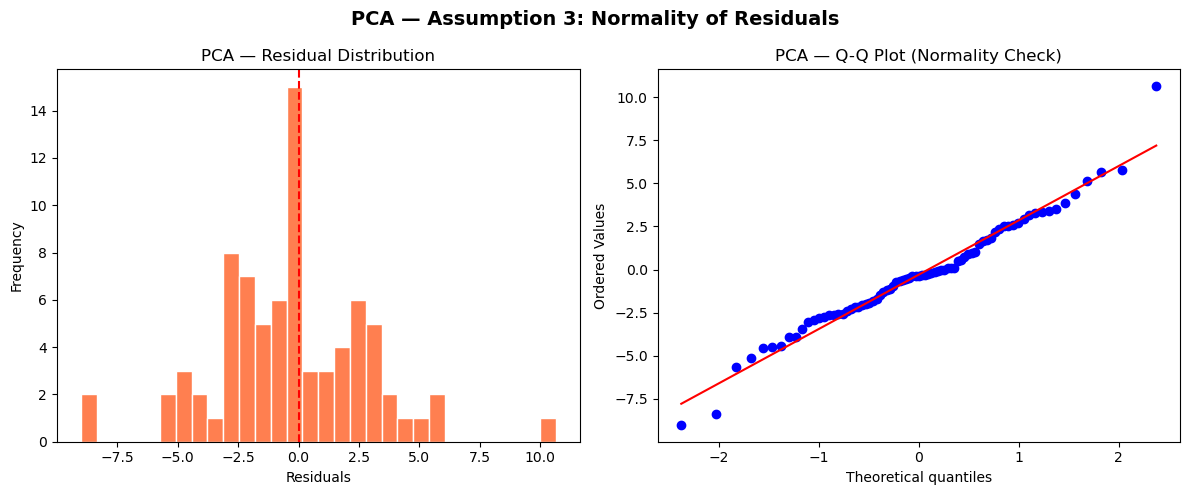

PCA — ASSUMPTION 3: NORMALITY OF RESIDUALS
Shapiro-Wilk Test:
Statistic:  0.9770
P-value:    0.1632
✅ Residuals are normally distributed (p > 0.05)


In [32]:
residuals_pca = y_test - pca_pipeline.predict(X_test)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].hist(residuals_pca, bins=30, color='coral', edgecolor='white')
axes[0].axvline(x=0, color='red', linestyle='--')
axes[0].set_xlabel('Residuals')
axes[0].set_ylabel('Frequency')
axes[0].set_title('PCA — Residual Distribution')

stats.probplot(residuals_pca, dist="norm", plot=axes[1])
axes[1].set_title('PCA — Q-Q Plot (Normality Check)')

plt.suptitle('PCA — Assumption 3: Normality of Residuals',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

stat, p_value = stats.shapiro(residuals_pca)

print("=" * 55)
print("PCA — ASSUMPTION 3: NORMALITY OF RESIDUALS")
print("Shapiro-Wilk Test:")
print("=" * 55)
print(f"Statistic:  {stat:.4f}")
print(f"P-value:    {p_value:.4f}")
if p_value > 0.05:
    print("✅ Residuals are normally distributed (p > 0.05)")
else:
    print("⚠️ Residuals not normally distributed (p < 0.05)")
print("=" * 55)


### 3. Check Assumption 4: Homoscedasticity

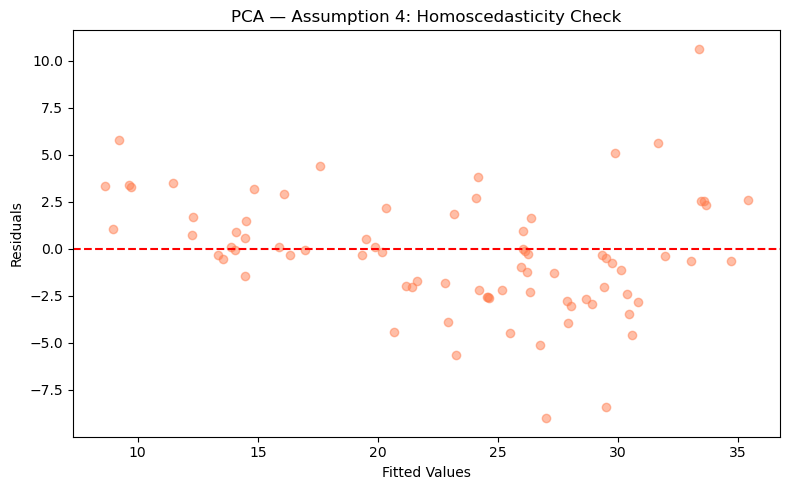


PCA — ASSUMPTION 4: HOMOSCEDASTICITY
Levene Test:
Statistic:  1.0937
P-value:    0.2989
✅ Constant variance confirmed (p > 0.05)


In [33]:
y_pred_pca    = pca_pipeline.predict(X_test)
residuals_pca = y_test - y_pred_pca

median_pred = np.median(y_pred_pca)
low_resid   = residuals_pca[y_pred_pca <= median_pred]
high_resid  = residuals_pca[y_pred_pca >  median_pred]

lev_stat, lev_p = levene(low_resid, high_resid)

fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(y_pred_pca, residuals_pca, alpha=0.5, color='coral')
ax.axhline(y=0, color='red', linestyle='--')
ax.set_xlabel('Fitted Values')
ax.set_ylabel('Residuals')
ax.set_title('PCA — Assumption 4: Homoscedasticity Check')
plt.tight_layout()
plt.show()

print("\n" + "=" * 55)
print("PCA — ASSUMPTION 4: HOMOSCEDASTICITY")
print("Levene Test:")
print("=" * 55)
print(f"Statistic:  {lev_stat:.4f}")
print(f"P-value:    {lev_p:.4f}")
if lev_p > 0.05:
    print("✅ Constant variance confirmed (p > 0.05)")
else:
    print("⚠️ Unequal variance detected (p < 0.05)")
    print("   → consider log transform on y")
print("=" * 55)

### 4. Residual Plot

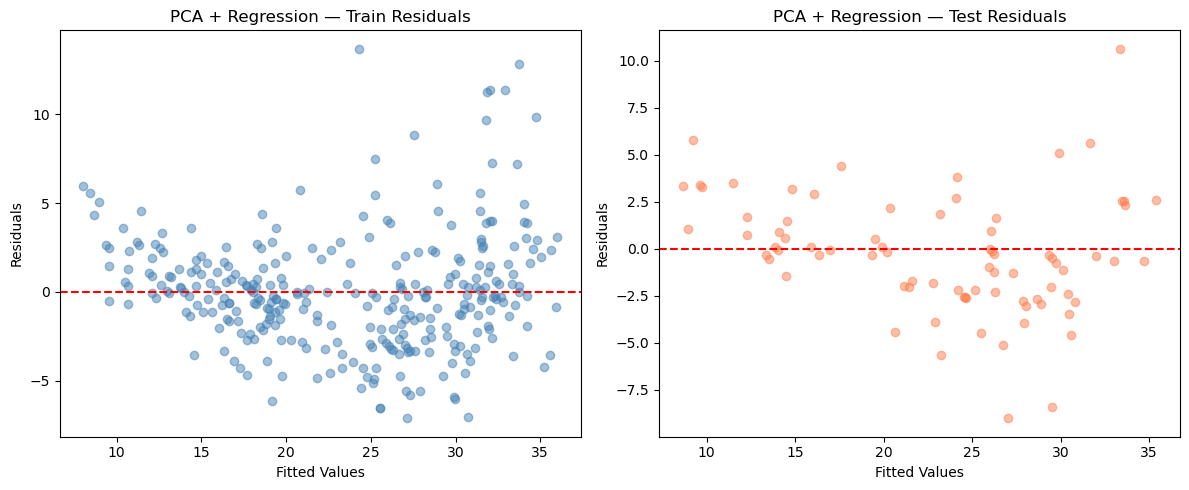

In [34]:
y_pred_train = pca_pipeline.predict(X_train)
y_pred_test  = pca_pipeline.predict(X_test)

residuals_train = y_train - y_pred_train
residuals_test  = y_test  - y_pred_test

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].scatter(y_pred_train, residuals_train, alpha=0.5, color='steelblue')
axes[0].axhline(y=0, color='red', linestyle='--')
axes[0].set_xlabel('Fitted Values')
axes[0].set_ylabel('Residuals')
axes[0].set_title('PCA + Regression — Train Residuals')

axes[1].scatter(y_pred_test, residuals_test, alpha=0.5, color='coral')
axes[1].axhline(y=0, color='red', linestyle='--')
axes[1].set_xlabel('Fitted Values')
axes[1].set_ylabel('Residuals')
axes[1].set_title('PCA + Regression — Test Residuals')

plt.tight_layout()
plt.show()

### 5. PCA: Features reducation

In [35]:
# Show explained variance for each PCA component
pca = pca_pipeline.named_steps['pca']

explained  = pca.explained_variance_ratio_
cumulative = np.cumsum(explained)

print(f"Total components selected: {pca.n_components_}")
print("-" * 55)
print(f"{'Component':<12} {'Variance %':>12}  {'Cumulative %':>12}")
print("-" * 55)
for i, (exp, cum) in enumerate(zip(explained, cumulative)):
    print(f"{i+1:<12} {exp*100:>11.2f}%  {cum*100:>11.2f}%")

Total components selected: 5
-------------------------------------------------------
Component      Variance %  Cumulative %
-------------------------------------------------------
1                  63.17%        63.17%
2                  13.80%        76.96%
3                  12.01%        88.97%
4                   3.90%        92.87%
5                   2.87%        95.75%


**Conclusion**

PCA reduced 7 features into 5 components — but in doing so:

Lost some information that was useful for prediction

Components are linear combinations of all features, so some signal got mixed/lost

With only 7 features, there wasn't much redundancy to remove in the first place

### 6. PCA + Regression Coefficients and Equation

In [36]:
pca_intercept = pca_pipeline.named_steps['model'].intercept_
pca_coef      = pca_pipeline.named_steps['model'].coef_
pca           = pca_pipeline.named_steps['pca']

print("\n" + "=" * 60)
print("PCA EQUATION:")
print("=" * 60)
print(f"MPG = {pca_intercept:.4f}")
for i, coef in enumerate(pca_coef):
    print(f"      {coef:+.4f} * PC{i+1}")


PCA EQUATION:
MPG = 23.5994
      -3.5361 * PC1
      +0.5306 * PC2
      -2.6633 * PC3
      -1.3870 * PC4
      +0.8202 * PC5


In [37]:
# Show what each component is made of
print("\n" + "=" * 60)
print("PCA COMPONENT COMPOSITION:")
print("=" * 60)
pca_features = pca_pipeline.named_steps['preprocessor'].get_feature_names_out()
for i, component in enumerate(pca.components_):
    print(f"\nPC{i+1}:")
    for feature, loading in zip(pca_features, component):
        if abs(loading) > 0.1:  # only show meaningful loadings
            print(f"  {loading:+.4f} * {feature}")


PCA COMPONENT COMPOSITION:

PC1:
  +0.4715 * num__weight
  +0.4981 * num__log_horsepower
  +0.4934 * num__displacement
  -0.3520 * num__acceleration
  -0.2682 * num__model
  -0.2053 * cat__cylinders_4
  +0.1933 * cat__cylinders_8

PC2:
  +0.3181 * num__weight
  +0.2019 * num__displacement
  +0.2638 * num__acceleration
  +0.8646 * num__model
  -0.1287 * cat__cylinders_4

PC3:
  +0.2746 * num__weight
  -0.1209 * num__log_horsepower
  +0.1384 * num__displacement
  +0.8064 * num__acceleration
  -0.4116 * num__model
  -0.1173 * cat__origin_3
  -0.1477 * cat__cylinders_4
  +0.1820 * cat__cylinders_6

PC4:
  -0.1544 * num__weight
  -0.2132 * num__acceleration
  -0.1773 * cat__origin_2
  -0.4212 * cat__cylinders_4
  +0.7680 * cat__cylinders_6
  -0.3556 * cat__cylinders_8

PC5:
  +0.1234 * num__acceleration
  -0.6483 * cat__origin_2
  +0.7248 * cat__origin_3
  +0.1148 * cat__cylinders_8


### 7. PCA + Regression Prediction vs Actual and Visualization

PCA + Regression — Predicted vs Actual (first 15 rows):
 Actual  Predicted  Error
   26.0      26.26  -0.26
   21.6      26.73  -5.13
   36.1      33.58   2.52
   26.0      26.13  -0.13
   27.0      30.47  -3.47
   28.0      30.39  -2.39
   13.0       9.73   3.27
   26.0      30.56  -4.56
   19.0      19.35  -0.35
   29.0      29.35  -0.35
   15.0      11.48   3.52
   19.0      22.91  -3.91
   16.9      16.98  -0.08
   29.0      29.73  -0.73
   16.2      20.65  -4.45


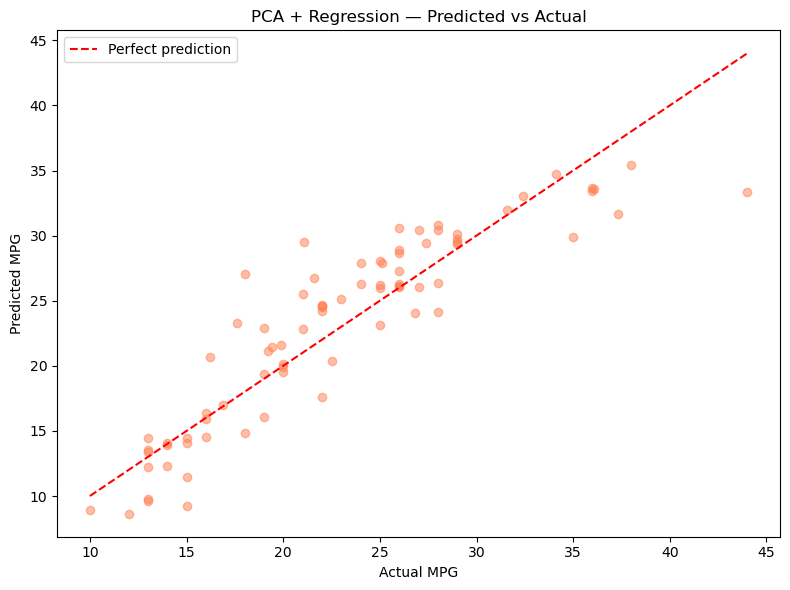

In [38]:
y_pred_test  = pca_pipeline.predict(X_test)

pca_pred_df = pd.DataFrame({
    'Actual':    y_test.values,
    'Predicted': y_pred_test,
    'Error':     y_test.values - y_pred_test
}).round(2)

print("PCA + Regression — Predicted vs Actual (first 15 rows):")
print(pca_pred_df.head(15).to_string(index=False))

fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(y_test, y_pred_test, alpha=0.5, color='coral')
ax.plot([y_test.min(), y_test.max()],
        [y_test.min(), y_test.max()],
        color='red', linestyle='--', label='Perfect prediction')
ax.set_xlabel('Actual MPG')
ax.set_ylabel('Predicted MPG')
ax.set_title('PCA + Regression — Predicted vs Actual')
ax.legend()
plt.tight_layout()
plt.show()


### 8. PCA + Regression Predicting MPG

In [39]:
new_car = pd.DataFrame({
    'weight':       [np.log(3000)],
    'log_horsepower':   [np.log(100)],
    'displacement': [np.log(200)],
    'acceleration':     [15.0],
    'model':            [80],
    'origin':           [3],
    'cylinders':        [4]
})

pca_pred = pca_pipeline.predict(new_car)[0]

print("=" * 40)
print("NEW CAR SPECIFICATIONS:")
print("=" * 40)
print(f"  Weight:       3000 lbs")
print(f"  Horsepower:   100 hp")
print(f"  Displacement: 200 cc")
print(f"  Acceleration: 15.0")
print(f"  Model year:   1980")
print(f"  Origin:       Japan (3)")
print(f"  Cylinders:    4")
print("=" * 40)
print(f"  PREDICTED MPG: {pca_pred:.2f} mpg")
print("=" * 40)

NEW CAR SPECIFICATIONS:
  Weight:       3000 lbs
  Horsepower:   100 hp
  Displacement: 200 cc
  Acceleration: 15.0
  Model year:   1980
  Origin:       Japan (3)
  Cylinders:    4
  PREDICTED MPG: 39.16 mpg


## Random Forest Model

### 1. Random Forest Pipeline

In [40]:
X = cars[['cylinders', 'weight', 'horsepower', 'displacement',
          'acceleration', 'model', 'origin']].copy()
y = cars['mpg']

# Log transform horsepower only
X['log_horsepower'] = np.log(X['horsepower'])
X = X.drop(columns=['horsepower'])

# Feature groups
numerical_features   = ['weight', 'log_horsepower', 'displacement',
                         'acceleration', 'model']
categorical_features = ['origin', 'cylinders']

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Preprocessor
preprocessor_rf = ColumnTransformer([
    ('num', StandardScaler(), numerical_features),
    ('cat', OneHotEncoder(drop='first', sparse_output=False), categorical_features)
])

# Pipeline
rf_pipeline = Pipeline([
    ('preprocessor', preprocessor_rf),
    ('model', RandomForestRegressor(
        n_estimators=100,
        max_depth=15,
        min_samples_split=5,
        min_samples_leaf=3,
        random_state=42
    ))
])

rf_pipeline.fit(X_train, y_train)

rf_train_r2 = r2_score(y_train, rf_pipeline.predict(X_train))
rf_test_r2  = r2_score(y_test,  rf_pipeline.predict(X_test))

print(f"Train R²:  {rf_train_r2:.4f}")
print(f"Test  R²:  {rf_test_r2:.4f}")
print(f"Gap:       {rf_train_r2 - rf_test_r2:.4f}")

Train R²:  0.9513
Test  R²:  0.8909
Gap:       0.0605


### 2. Residual Plot

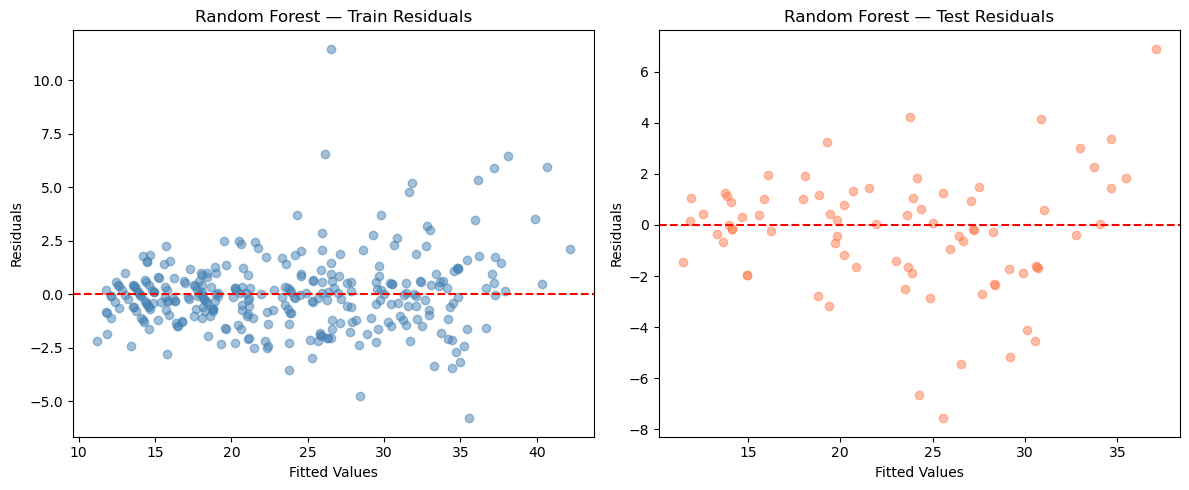

In [41]:
y_pred_train = rf_pipeline.predict(X_train)
y_pred_test  = rf_pipeline.predict(X_test)

residuals_train = y_train - y_pred_train
residuals_test  = y_test  - y_pred_test

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].scatter(y_pred_train, residuals_train, alpha=0.5, color='steelblue')
axes[0].axhline(y=0, color='red', linestyle='--')
axes[0].set_xlabel('Fitted Values')
axes[0].set_ylabel('Residuals')
axes[0].set_title('Random Forest — Train Residuals')

axes[1].scatter(y_pred_test, residuals_test, alpha=0.5, color='coral')
axes[1].axhline(y=0, color='red', linestyle='--')
axes[1].set_xlabel('Fitted Values')
axes[1].set_ylabel('Residuals')
axes[1].set_title('Random Forest — Test Residuals')

plt.tight_layout()
plt.show()

### 3. Random Forest Prediction vs Actual and Visualization

Random Forest — Predicted vs Actual (first 15 rows):
 Actual  Predicted  Error
   26.0      26.62  -0.62
   21.6      23.00  -1.40
   36.1      34.66   1.44
   26.0      30.09  -4.09
   27.0      27.22  -0.22
   28.0      28.28  -0.28
   13.0      12.59   0.41
   26.0      28.30  -2.30
   19.0      19.72  -0.72
   29.0      30.69  -1.69
   15.0      14.09   0.91
   19.0      20.18  -1.18
   16.9      15.89   1.01
   29.0      27.53   1.47
   16.2      19.39  -3.19


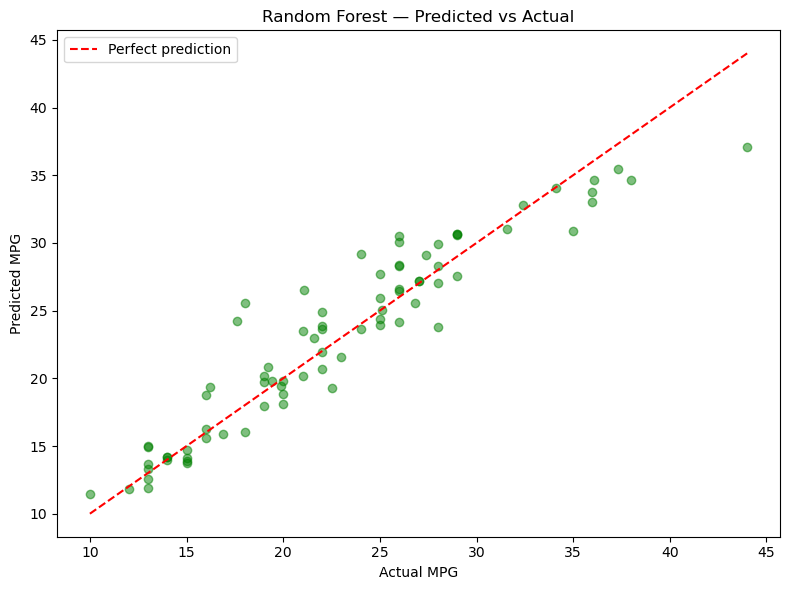

In [42]:
y_pred_test  = rf_pipeline.predict(X_test)

rf_pred_df = pd.DataFrame({
    'Actual':    y_test.values,
    'Predicted': y_pred_test,
    'Error':     y_test.values - y_pred_test
}).round(2)

print("Random Forest — Predicted vs Actual (first 15 rows):")
print(rf_pred_df.head(15).to_string(index=False))

fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(y_test, y_pred_test, alpha=0.5, color='green')
ax.plot([y_test.min(), y_test.max()],
        [y_test.min(), y_test.max()],
        color='red', linestyle='--', label='Perfect prediction')
ax.set_xlabel('Actual MPG')
ax.set_ylabel('Predicted MPG')
ax.set_title('Random Forest — Predicted vs Actual')
ax.legend()
plt.tight_layout()
plt.show()

### 4. Random Forest Predicting MPG

In [43]:
new_car = pd.DataFrame({
    'weight':       [np.log(3000)],
    'log_horsepower':   [np.log(100)],
    'displacement': [np.log(200)],
    'acceleration':     [15.0],
    'model':            [80],
    'origin':           [3],
    'cylinders':        [4]
})

rf_pred = rf_pipeline.predict(new_car)[0]

print("=" * 40)
print("NEW CAR SPECIFICATIONS:")
print("=" * 40)
print(f"  Weight:       3000 lbs")
print(f"  Horsepower:   100 hp")
print(f"  Displacement: 200 cc")
print(f"  Acceleration: 15.0")
print(f"  Model year:   1980")
print(f"  Origin:       Japan (3)")
print(f"  Cylinders:    4")
print("=" * 40)
print(f"  PREDICTED MPG: {rf_pred:.2f} mpg")
print("=" * 40)

NEW CAR SPECIFICATIONS:
  Weight:       3000 lbs
  Horsepower:   100 hp
  Displacement: 200 cc
  Acceleration: 15.0
  Model year:   1980
  Origin:       Japan (3)
  Cylinders:    4
  PREDICTED MPG: 33.02 mpg


### 5. Model Tuning

#### 5.a) Random Forest Tuning Round 1:

In [44]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'model__n_estimators':      [100, 200],
    'model__max_depth':         [5, 10, 15],
    'model__min_samples_split': [5, 10],
    'model__min_samples_leaf':  [3, 5]
}

grid_search = GridSearchCV(
    rf_pipeline,
    param_grid,
    cv=5,
    scoring='r2',
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

best_rf    = grid_search.best_estimator_
rf_train_r2 = r2_score(y_train, best_rf.predict(X_train))
rf_test_r2  = r2_score(y_test,  best_rf.predict(X_test))

print(f"Best params: {grid_search.best_params_}")
print(f"RF Train R²:    {rf_train_r2:.4f}")
print(f"RF Test  R²:    {rf_test_r2:.4f}")
print(f"RF Gap:         {rf_train_r2 - rf_test_r2:.4f}")

Best params: {'model__max_depth': 15, 'model__min_samples_leaf': 3, 'model__min_samples_split': 5, 'model__n_estimators': 100}
RF Train R²:    0.9513
RF Test  R²:    0.8909
RF Gap:         0.0605


In [45]:
new_car = pd.DataFrame({
    'weight':       [np.log(3000)],
    'log_horsepower':   [np.log(100)],
    'displacement': [np.log(200)],
    'acceleration':     [15.0],
    'model':            [80],
    'origin':           [3],
    'cylinders':        [4]
})

rf_pred = rf_pipeline.predict(new_car)[0]

print("=" * 40)
print("NEW CAR SPECIFICATIONS:")
print("=" * 40)
print(f"  Weight:       3000 lbs")
print(f"  Horsepower:   100 hp")
print(f"  Displacement: 200 cc")
print(f"  Acceleration: 15.0")
print(f"  Model year:   1980")
print(f"  Origin:       Japan (3)")
print(f"  Cylinders:    4")
print("=" * 40)
print(f"  PREDICTED MPG: {rf_pred:.2f} mpg")
print("=" * 40)

NEW CAR SPECIFICATIONS:
  Weight:       3000 lbs
  Horsepower:   100 hp
  Displacement: 200 cc
  Acceleration: 15.0
  Model year:   1980
  Origin:       Japan (3)
  Cylinders:    4
  PREDICTED MPG: 33.02 mpg


### 5.b) Random Forest Tuning Round 2:

In [46]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'model__n_estimators':      [100, 200, 300],
    'model__max_depth':         [15, 20, 25],     # explore deeper
    'model__min_samples_split': [2, 5],
    'model__min_samples_leaf':  [1, 3]
}

grid_search = GridSearchCV(
    rf_pipeline,
    param_grid,
    cv=5,
    scoring='r2',
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

best_rf    = grid_search.best_estimator_
rf_train_r2   = r2_score(y_train, best_rf.predict(X_train))
rf_test_r2    = r2_score(y_test,  best_rf.predict(X_test))

print(f"Best params: {grid_search.best_params_}")
print(f"RF Train R²:    {rf_train_r2:.4f}")
print(f"RF Test  R²:    {rf_test_r2:.4f}")
print(f"RF Gap:         {rf_train_r2 - rf_test_r2:.4f}")

Best params: {'model__max_depth': 15, 'model__min_samples_leaf': 1, 'model__min_samples_split': 5, 'model__n_estimators': 300}
RF Train R²:    0.9739
RF Test  R²:    0.8972
RF Gap:         0.0766


In [47]:
new_car = pd.DataFrame({
    'weight':       [np.log(3000)],
    'log_horsepower':   [np.log(100)],
    'displacement': [np.log(200)],
    'acceleration':     [15.0],
    'model':            [80],
    'origin':           [3],
    'cylinders':        [4]
})

rf_pred = rf_pipeline.predict(new_car)[0]

print("=" * 40)
print("NEW CAR SPECIFICATIONS:")
print("=" * 40)
print(f"  Weight:       3000 lbs")
print(f"  Horsepower:   100 hp")
print(f"  Displacement: 200 cc")
print(f"  Acceleration: 15.0")
print(f"  Model year:   1980")
print(f"  Origin:       Japan (3)")
print(f"  Cylinders:    4")
print("=" * 40)
print(f"  PREDICTED MPG: {rf_pred:.2f} mpg")
print("=" * 40)

NEW CAR SPECIFICATIONS:
  Weight:       3000 lbs
  Horsepower:   100 hp
  Displacement: 200 cc
  Acceleration: 15.0
  Model year:   1980
  Origin:       Japan (3)
  Cylinders:    4
  PREDICTED MPG: 33.02 mpg


## Model Comparison

###  1. Model Performance Comparison — all models

In [48]:
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import numpy as np

# ============================================================
# MODEL PERFORMANCE COMPARISON
# ============================================================

# --- Calculate all metrics ---
models = {
    'PCA + Regression': pca_pipeline,
    'Lasso CV':         lasso_cv_pipeline,
    'Ridge CV':         ridge_pipeline,
    'Random Forest':    rf_pipeline
}

results = {}
for name, pipeline in models.items():
    train_pred = pipeline.predict(X_train)
    test_pred  = pipeline.predict(X_test)
    results[name] = {
        'train_r2':  r2_score(y_train, train_pred),
        'test_r2':   r2_score(y_test,  test_pred),
        'gap':       r2_score(y_train, train_pred) - r2_score(y_test, test_pred),
        'mae':       mean_absolute_error(y_test,          test_pred),
        'mse':       mean_squared_error(y_test,           test_pred),
        'rmse':      np.sqrt(mean_squared_error(y_test,   test_pred))
    }

# --- Print comparison ---
print("\n" + "=" * 80)
print(f"{'Model':<25} {'Train R²':>8}  {'Test R²':>8}  {'Gap':>6}  {'MAE':>6}  {'MSE':>7}  {'RMSE':>6}")
print("=" * 80)
for name, metrics in results.items():
    print(f"{name:<25} {metrics['train_r2']:>8.4f}  {metrics['test_r2']:>8.4f}  "
          f"{metrics['gap']:>6.4f}  {metrics['mae']:>6.4f}  "
          f"{metrics['mse']:>7.4f}  {metrics['rmse']:>6.4f}")
print("=" * 80)


Model                     Train R²   Test R²     Gap     MAE      MSE    RMSE
PCA + Regression            0.8325    0.8068  0.0258  2.3654   9.8623  3.1404
Lasso CV                    0.8603    0.8317  0.0286  2.2976   8.5923  2.9313
Ridge CV                    0.8581    0.8301  0.0279  2.2869   8.6694  2.9444
Random Forest               0.9513    0.8909  0.0605  1.7117   5.5699  2.3601


### 2. Final Model Ranking 

#### Performance Summary

| Rank | Model | Train R² | Test R² | Gap | MAE | RMSE | Verdict |
|------|-------|----------|---------|-----|-----|------|---------|
| 🥇 1st | Random Forest | 0.9513 | 0.8909 | 0.0605 | 1.7117 | 2.3601 | Best prediction |
| 🥈 2nd | Lasso CV | 0.8603 | 0.8317 | 0.0286 | 2.2976 | 2.9313 | Best linear, most stable |
| 🥉 3rd | Ridge CV | 0.8581 | 0.8301 | 0.0279 | 2.2869 | 2.9444 | Very close to Lasso |
| 4th | PCA + Regression | 0.8325 | 0.8068 | 0.0258 | 2.3654 | 3.1404 | Weakest prediction |

#### Conclusion

**Random Forest** is the best performing model overall:
- Highest Test R² **(0.8909)** — explains 89% of variance in mpg
- Lowest MAE **(1.7117)** — predictions off by only 1.71 mpg on average
- Lowest RMSE **(2.3601)** — best at handling large errors
- Largest gap **(0.0605)** — some overfitting present but acceptable

**Lasso CV** is the best linear model:
- Strong Test R² **(0.8317)** with smallest gap **(0.0286)**
- Most stable and consistent between train and test
- Most interpretable — automatically removed `cylinders_6`
  as a non-contributing feature
- Best choice when understanding which features drive mpg matters

**Ridge CV** performs virtually identical to Lasso:
- Test R² **(0.8301)** — only 0.0016 behind Lasso
- Kept all features including weak ones
- Confirms Lasso was correct to remove `cylinders_6`

**PCA + Regression** is the weakest model:
- Lowest Test R² **(0.8068)** and highest RMSE **(3.1404)**
- Compressed features into 5 components — some predictive
  information lost in the process
- Best gap **(0.0258)** — most consistent but least accurate

#### Final Recommendation

| Priority | Model |
|----------|-------|
| Best prediction accuracy | Random Forest (Test R²=0.8909) |
| Best interpretability | Lasso CV (clear coefficients) |
| Best stability | Lasso CV (Gap=0.0286) |
| Production deployment | Random Forest |

## New car MPG prediction — model comparison

In [49]:
new_car = pd.DataFrame({
    'weight':       [np.log(3000)],
    'log_horsepower':   [np.log(100)],
    'displacement': [np.log(200)],
    'acceleration':     [15.0],
    'model':            [80],
    'origin':           [3],
    'cylinders':        [4]
})

# ============================================================
# PREDICTIONS
# ============================================================
lasso_pred = lasso_cv_pipeline.predict(new_car)[0]
ridge_pred = ridge_pipeline.predict(new_car)[0]
pca_pred   = pca_pipeline.predict(new_car)[0]
rf_pred    = rf_pipeline.predict(new_car)[0]

# ============================================================
# COMPARISON
# ============================================================
print("=" * 40)
print("NEW CAR SPECIFICATIONS:")
print("=" * 40)
print(f"  Weight:       3000 lbs")
print(f"  Horsepower:   100 hp")
print(f"  Displacement: 200 cc")
print(f"  Acceleration: 15.0")
print(f"  Model year:   1980")
print(f"  Origin:       Japan (3)")
print(f"  Cylinders:    4")
print("=" * 40)
print("PREDICTED MPG:")
print("=" * 40)
print(f"  Lasso CV:         {lasso_pred:.2f} mpg")
print(f"  Ridge CV:         {ridge_pred:.2f} mpg")
print(f"  PCA + Regression: {pca_pred:.2f} mpg")
print(f"  Random Forest:    {rf_pred:.2f} mpg")
print("=" * 40)

NEW CAR SPECIFICATIONS:
  Weight:       3000 lbs
  Horsepower:   100 hp
  Displacement: 200 cc
  Acceleration: 15.0
  Model year:   1980
  Origin:       Japan (3)
  Cylinders:    4
PREDICTED MPG:
  Lasso CV:         37.34 mpg
  Ridge CV:         37.37 mpg
  PCA + Regression: 39.16 mpg
  Random Forest:    33.02 mpg
